# A Variational Bar-Pointer Model, From First Principles

This notebook builds a **variational bar-pointer model** for joint beat / downbeat / tempo / meter
tracking, end to end and with nothing hidden:

1. the generative story (a *bar pointer* sweeping around a circle),
2. the amortized inference model,
3. the **full ELBO derivation, with no skipped steps**, including the closed-form KL divergences and
   reparameterized samplers for all three latent families,
4. a from-scratch implementation where **every loss term is traceable to an equation**,
5. **Experiment 1** — training with the plain negative ELBO, which *fails* (posterior collapse), and an
   autopsy that shows **why** it fails,
6. **Experiment 2** — the same model plus one dense auxiliary loss (a *sawtooth phase target*), which works,
7. a quantitative probe showing that the collapse is the ELBO's **preferred optimum**, not an optimization
   accident — which is exactly why the auxiliary loss is needed.

**What is reused vs. implemented.** Following the "don't reinvent the wheel" rule, we *reuse* published
code/artifacts where they exist: audio features come from the frozen **Beat This** frontend
(Foscarin, Schlüter & Widmer, ISMIR 2024) via a precomputed cache; `torch.distributions` supplies the
trusted samplers and the Normal/Categorical KLs (we derive them anyway, and use the library as a
*verification oracle*); `torch.nn.functional.gumbel_softmax` supplies the categorical relaxation
(Jang et al. / Maddison et al., ICLR 2017); and `mir_eval` (Raffel et al., ISMIR 2014) scores beat
tracking. Everything specific to this model — the dynamics, the wrapped Cauchy KL and its reparameterized sampler,
the ELBO, the training loop, the geometric read-out — is implemented *in this notebook*.


In [ ]:
%matplotlib inline
import sys, os
# Everything derived in this notebook is IMPLEMENTED in the repo package (config/, model/, data/,
# losses.py) and IMPORTED here; each import is followed by a show/verify cell so the derivation
# stays checkable. Supporting code (plotting, diagnostics) lives in notebooks/nblib/.
_nblib_parent = next(d for d in (".", "notebooks", "..") if os.path.isdir(os.path.join(d, "nblib")))
if _nblib_parent not in sys.path:
    sys.path.insert(0, _nblib_parent)

import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical, Normal, Laplace, kl_divergence
from dataclasses import dataclass

from nblib.setup import (TWO_PI, FPS, FRAMES_PER_SECOND, FEATURE_DIM, BEATS_PER_BAR,
                         READOUT_BEATS_PER_BAR, ACTIVE_FRONTEND, DEVICE, COLOR_BLUE, COLOR_AQUA,
                         COLOR_YELLOW, COLOR_VIOLET, COLOR_RED, rad_per_frame_to_bpm,
                         bpm_to_rad_per_frame, set_all_seeds)
from nblib.data import load_cached_songs, sample_training_crops
from nblib.evaluation import evaluate_geometric_readout, evaluate_prior_readout, evaluate_filter_readout
from nblib.plotting import (plot_training_history, plot_phase_trajectories, print_leak_table,
                            plot_raw_material)
from nblib.diagnostics import (plot_tempo_increment_fit, plot_phase_residual_fit,
                               plot_meter_content_fit, pure_negative_elbo_accounting)

torch.manual_seed(0)
print(f"torch {torch.__version__} | device: {DEVICE}")
print(f"frontend: {ACTIVE_FRONTEND.name} | fps {FPS:.4f} | feature_dim {FEATURE_DIM}")


## 1. The ELBO Derivation

**Setup.** The raw audio $x$ (waveform or spectrogram) is first mapped to a feature sequence by a feature extractor (e.g. Beat This, Beat Transformer, etc.):

$$h_{1:T} = \mathrm{feature\_extractor}(x).$$

Each $h_t$ is already globally contextual — the feature extractor attends over all of $x$. The variational bar-pointer model is a sequential VAE built **on top of** $h$: its per-frame latent is $z_t = (\dot\phi_t, \phi_t, m_t)$ (tempo, bar phase, meter), and it explains the per-frame beat/downbeat events $b_t \in \{0,1\}^2$.

We maximize the conditional log-marginal-likelihood $\log p(b_{1:T} \mid h_{1:T})$.

**From the marginal to a lower bound.**

$$\log p(b_{1:T}\mid h_{1:T}) = \log \int p(b_{1:T}, z_{1:T}\mid h_{1:T})\, dz_{1:T} \qquad [\text{marginalize the latents}]$$

$$= \log \int q(z_{1:T}\mid b_{1:T}, h_{1:T})\, \frac{p(b_{1:T}, z_{1:T}\mid h_{1:T})}{q(z_{1:T}\mid b_{1:T}, h_{1:T})}\, dz_{1:T} \qquad [\text{multiply and divide by } q]$$

$$= \log \mathbb{E}_{q(z_{1:T}\mid b_{1:T}, h_{1:T})}\!\left[\frac{p(b_{1:T}, z_{1:T}\mid h_{1:T})}{q(z_{1:T}\mid b_{1:T}, h_{1:T})}\right] \qquad [\text{recognize the expectation}]$$

$$\ge \mathbb{E}_{q(z_{1:T}\mid b_{1:T}, h_{1:T})}\!\left[\log \frac{p(b_{1:T}, z_{1:T}\mid h_{1:T})}{q(z_{1:T}\mid b_{1:T}, h_{1:T})}\right] \equiv \mathcal{L} \qquad [\text{Jensen: } \log\mathbb{E}[X]\ge\mathbb{E}[\log X]]$$

The gap is exactly $D_{\mathrm{KL}}\!\left(q(z_{1:T}\mid b_{1:T},h_{1:T}) \,\middle\|\, p(z_{1:T}\mid b_{1:T},h_{1:T})\right) \ge 0$. Splitting the log-ratio,

$$\mathcal{L} = \mathbb{E}_{q(z_{1:T}\mid b_{1:T}, h_{1:T})}\!\left[\log p(b_{1:T}, z_{1:T}\mid h_{1:T}) - \log q(z_{1:T}\mid b_{1:T}, h_{1:T})\right].$$

### 1.1 Expanding the joint $p(b_{1:T}, z_{1:T}\mid h_{1:T})$

We expand the joint by the **chain rule**, peeling off one variable at a time in the order the model generates them — $z_1, b_1, z_2, b_2, \dots, z_T, b_T$ — and making **no independence assumptions yet**. Each step splits the leftmost remaining variable off the front with $p(A, R\mid C) = p(A\mid C)\,p(R\mid A, C)$; every factor keeps its full history, and $h_{1:T}$ stays in every condition (it is given throughout).

We start by expanding $b_{1:T}$ and $z_{1:T}$:

$$p(b_{1:T}, z_{1:T}\mid h_{1:T}) = p(z_1, b_1, z_2, b_2, \dots, z_T, b_T \mid h_{1:T})$$
Peel $z_1$:

$$p(z_1, b_1, z_2, b_2, \dots, z_T, b_T \mid h_{1:T}) = p(z_1\mid h_{1:T})\; p(b_1, z_2, b_2, \dots, z_T, b_T \mid z_1, h_{1:T}).$$

Peel $b_1$:

$$= p(z_1\mid h_{1:T})\; p(b_1\mid z_1, h_{1:T})\; p(z_2, b_2, \dots, z_T, b_T \mid z_1, b_1, h_{1:T}).$$

Peel $z_2$:

$$= p(z_1\mid h_{1:T})\; p(b_1\mid z_1, h_{1:T})\; p(z_2\mid z_1, b_1, h_{1:T})\; p(b_2, z_3, \dots, b_T \mid z_1, b_1, z_2, h_{1:T}).$$

Peel $b_2$:

$$= p(z_1\mid h_{1:T})\; p(b_1\mid z_1, h_{1:T})\; p(z_2\mid z_1, b_1, h_{1:T})\; p(b_2\mid z_1, b_1, z_2, h_{1:T})\; p(z_3, \dots, b_T \mid z_1, b_1, z_2, b_2, h_{1:T}).$$

Peel $z_3$, then $b_3$:

$$= p(z_1\mid h_{1:T})\; p(b_1\mid z_1, h_{1:T})\; p(z_2\mid z_1, b_1, h_{1:T})\; p(b_2\mid z_1, b_1, z_2, h_{1:T})\; p(z_3\mid z_1, b_1, z_2, b_2, h_{1:T})\; p(b_3\mid z_1, b_1, z_2, b_2, z_3, h_{1:T})\; p(z_4, \dots, b_T \mid z_{1:3}, b_{1:3}, h_{1:T}).$$

The pattern is now clear: each **state** $z_t$ conditions on everything generated before it — all earlier latents $z_{1:t-1}$ and all earlier events $b_{1:t-1}$ — and each **emission** $b_t$ conditions on that same history plus the just-drawn $z_t$. Peeling all the way to $t = T$:

$$p(b_{1:T}, z_{1:T}\mid h_{1:T}) = \prod_{t=1}^{T} \underbrace{p(z_t\mid z_{1:t-1}, b_{1:t-1}, h_{1:T})}_{\text{state}}\; \underbrace{p(b_t\mid z_{1:t}, b_{1:t-1}, h_{1:T})}_{\text{emission}},$$

with the convention that $z_{1:0}$ and $b_{1:0}$ are empty (so the $t=1$ state factor is just $p(z_1\mid h_{1:T})$). This line is **exact** — pure chain rule, no modeling assumptions.

**Only now do we apply the model's independence assumptions,** one per factor:

1. **State — first-order Markov, current frame only.** The bar-pointer state is a Markov chain whose transition is driven by the previous state and the current audio frame. Every conditioning variable except $z_{t-1}$ and $h_t$ drops:
$$p(z_t\mid z_{1:t-1}, b_{1:t-1}, h_{1:T}) \;\longrightarrow\; p(z_t\mid z_{t-1}, h_t), \qquad\text{and}\qquad p(z_1\mid h_{1:T}) \;\longrightarrow\; p(z_1\mid h_1).$$

2. **Emission — local.** An event depends only on the current state (the decoder reads $z_t$ alone):
$$p(b_t\mid z_{1:t}, b_{1:t-1}, h_{1:T}) \;\longrightarrow\; p(b_t\mid z_t).$$

Substitute both back into the exact product:

$$p(b_{1:T}, z_{1:T}\mid h_{1:T}) = p(z_1\mid h_1)\, p(b_1\mid z_1)\prod_{t=2}^{T} p(z_t\mid z_{t-1}, h_t)\, p(b_t\mid z_t).$$

Take the log and turn the product into a sum ($\log\prod = \sum\log$), folding the $t=1$ emission into the beat sum:

$$\log p(b_{1:T}, z_{1:T}\mid h_{1:T}) = \log p(z_1\mid h_1) + \sum_{t=1}^{T}\log p(b_t\mid z_t) + \sum_{t=2}^{T}\log p(z_t\mid z_{t-1}, h_t).$$

The whole-sequence conditioning $h_{1:T}$ has collapsed to the per-frame $h_t$: the frozen frontend already did the sequence mixing, so the VAE's own dependence on $h$ is one frame at a time.

### 1.2 Expanding the posterior $q(z_{1:T}\mid b_{1:T}, h_{1:T})$

We peel the posterior the same way, one variable at a time — but now **only the latents $z_t$ get peeled.** The observations $b_{1:T}$ and features $h_{1:T}$ sit on the right of the conditioning bar throughout: they are *given* to the encoder, never generated by it, so they ride along in every factor's condition and are never split off. Again, **no assumptions yet** — use $q(A, R\mid C) = q(A\mid C)\,q(R\mid A, C)$ with $C = (b_{1:T}, h_{1:T})$ held fixed.

Peel $z_1$:

$$q(z_1, z_2, \dots, z_T \mid b_{1:T}, h_{1:T}) = q(z_1\mid b_{1:T}, h_{1:T})\; q(z_2, \dots, z_T \mid z_1, b_{1:T}, h_{1:T}).$$

Peel $z_2$:

$$= q(z_1\mid b_{1:T}, h_{1:T})\; q(z_2\mid z_1, b_{1:T}, h_{1:T})\; q(z_3, \dots, z_T \mid z_1, z_2, b_{1:T}, h_{1:T}).$$

Peel $z_3$:

$$= q(z_1\mid b_{1:T}, h_{1:T})\; q(z_2\mid z_1, b_{1:T}, h_{1:T})\; q(z_3\mid z_1, z_2, b_{1:T}, h_{1:T})\; q(z_4, \dots, z_T \mid z_{1:3}, b_{1:T}, h_{1:T}).$$

The pattern: each $z_t$ conditions on all earlier latents $z_{1:t-1}$ and on the **entire** observation record $(b_{1:T}, h_{1:T})$. Peeling all the way to $t = T$:

$$q(z_{1:T}\mid b_{1:T}, h_{1:T}) = \prod_{t=1}^{T} q(z_t\mid z_{1:t-1}, b_{1:T}, h_{1:T}),$$

with $z_{1:0}$ empty (so the $t=1$ factor is $q(z_1\mid b_{1:T}, h_{1:T})$). This line is **exact** — pure chain rule, no modeling assumptions.

**Only now do we apply the assumptions,** matching the encoder we build in §3:

1. **First-order Markov (autoregressive in $z$).** The encoder carries only the previous latent forward, so the earlier latents drop:
$$q(z_t\mid z_{1:t-1}, b_{1:T}, h_{1:T}) \;\longrightarrow\; q(z_t\mid z_{t-1}, b_{1:T}, h_{1:T}).$$
2. **Per-frame conditioning.** The encoder is a per-frame head reading one frame of the (already globally-contextualized) features and its event channel — no sequence model of its own — so the whole record collapses to the current frame:
$$q(z_t\mid z_{t-1}, b_{1:T}, h_{1:T}) \;\longrightarrow\; q(z_t\mid z_{t-1}, b_t, h_t), \qquad\text{and}\qquad q(z_1\mid b_{1:T}, h_{1:T}) \;\longrightarrow\; q(z_1\mid b_1, h_1).$$

Substitute both back into the exact product:

$$q(z_{1:T}\mid b_{1:T}, h_{1:T}) = q(z_1\mid b_1, h_1)\prod_{t=2}^{T} q(z_t\mid z_{t-1}, b_t, h_t).$$

Take the log and turn the product into a sum:

$$\log q(z_{1:T}\mid b_{1:T}, h_{1:T}) = \log q(z_1\mid b_1, h_1) + \sum_{t=2}^{T}\log q(z_t\mid z_{t-1}, b_t, h_t).$$

Note the one structural difference from the joint: the posterior may read its event channel $b_t$ (that is the encoder's job at training time), whereas the prior may not — that asymmetry is exactly what the transition KL in §1.3 charges for.

### 1.3 Combining

Recall the bound from the top of this section,

$$\mathcal{L} = \mathbb{E}_{q(z_{1:T}\mid b_{1:T}, h_{1:T})}\!\left[\log p(b_{1:T}, z_{1:T}\mid h_{1:T}) - \log q(z_{1:T}\mid b_{1:T}, h_{1:T})\right],$$

and the two log-expansions we just derived — the joint from §1.1 and the posterior from §1.2:

$$\log p(b_{1:T}, z_{1:T}\mid h_{1:T}) = \log p(z_1\mid h_1) + \sum_{t=1}^{T}\log p(b_t\mid z_t) + \sum_{t=2}^{T}\log p(z_t\mid z_{t-1}, h_t),$$

$$\log q(z_{1:T}\mid b_{1:T}, h_{1:T}) = \log q(z_1\mid b_1, h_1) + \sum_{t=2}^{T}\log q(z_t\mid z_{t-1}, b_t, h_t).$$

**Step 1 — substitute both expansions** into the bracket $[\,\log p - \log q\,]$:

$$\mathcal{L} = \mathbb{E}_{q}\!\left[\log p(z_1\mid h_1) + \sum_{t=1}^{T}\log p(b_t\mid z_t) + \sum_{t=2}^{T}\log p(z_t\mid z_{t-1}, h_t) - \log q(z_1\mid b_1, h_1) - \sum_{t=2}^{T}\log q(z_t\mid z_{t-1}, b_t, h_t)\right].$$

**Step 2 — group $p$ against $q$, term by term.** The reconstruction sum $\sum_t \log p(b_t\mid z_t)$ has no $q$ counterpart (the posterior never generated the $b$'s — they sit in its condition). The $t=1$ prior pairs with the $t=1$ posterior; each $t\ge 2$ transition prior pairs with the posterior factor at the *same* $t$:

$$\mathcal{L} = \mathbb{E}_{q}\!\left[\;\underbrace{\sum_{t=1}^{T}\log p(b_t\mid z_t)}_{\text{reconstruction}} + \underbrace{\Big(\log p(z_1\mid h_1) - \log q(z_1\mid b_1, h_1)\Big)}_{t=1} + \underbrace{\sum_{t=2}^{T}\Big(\log p(z_t\mid z_{t-1}, h_t) - \log q(z_t\mid z_{t-1}, b_t, h_t)\Big)}_{t\,\ge\,2}\;\right].$$

Fold each paired difference into one log-ratio ($\log a - \log b = \log\tfrac{a}{b}$):

$$\mathcal{L} = \mathbb{E}_{q}\!\left[\sum_{t=1}^{T}\log p(b_t\mid z_t) + \log\frac{p(z_1\mid h_1)}{q(z_1\mid b_1, h_1)} + \sum_{t=2}^{T}\log\frac{p(z_t\mid z_{t-1}, h_t)}{q(z_t\mid z_{t-1}, b_t, h_t)}\right].$$

**Step 3 — distribute the expectation** (linearity, $\mathbb{E}[X+Y]=\mathbb{E}[X]+\mathbb{E}[Y]$), pushing the single $\mathbb{E}_{q(z_{1:T})}$ onto each summand:

$$\mathcal{L} = \sum_{t=1}^{T}\mathbb{E}_{q(z_{1:T})}\!\left[\log p(b_t\mid z_t)\right] + \mathbb{E}_{q(z_{1:T})}\!\left[\log\frac{p(z_1\mid h_1)}{q(z_1\mid b_1, h_1)}\right] + \sum_{t=2}^{T}\mathbb{E}_{q(z_{1:T})}\!\left[\log\frac{p(z_t\mid z_{t-1}, h_t)}{q(z_t\mid z_{t-1}, b_t, h_t)}\right].$$

Each expectation is still over the *full* posterior, but every integrand touches only one or two latents. Collapse each to the marginal it needs — one type at a time.

**Step 4a — reconstruction $\to$ marginal at $t$.** The integrand $\log p(b_t\mid z_t)$ depends on $z_t$ alone; integrating the full posterior over every *other* latent leaves the marginal $q(z_t\mid b_{1:T},h_{1:T})$, abbreviated $q(z_t)$:

$$\mathbb{E}_{q(z_{1:T})}\!\left[\log p(b_t\mid z_t)\right] = \int q(z_{1:T})\,\log p(b_t\mid z_t)\;dz_{1:T} = \int \underbrace{\Big(\textstyle\int q(z_{1:T})\,dz_{\neq t}\Big)}_{=\;q(z_t)}\log p(b_t\mid z_t)\;dz_t = \mathbb{E}_{q(z_t)}\!\left[\log p(b_t\mid z_t)\right].$$

**Step 4b — initial term $\to$ a KL.** Same reduction to $z_1$, then the definition of the KL divergence:

$$\mathbb{E}_{q(z_{1:T})}\!\left[\log\frac{p(z_1\mid h_1)}{q(z_1\mid b_1, h_1)}\right] = \mathbb{E}_{q(z_1)}\!\left[\log\frac{p(z_1\mid h_1)}{q(z_1\mid b_1, h_1)}\right] = -\,\mathbb{E}_{q(z_1)}\!\left[\log\frac{q(z_1\mid b_1, h_1)}{p(z_1\mid h_1)}\right] = -\,D_{\mathrm{KL}}\!\left(q(z_1\mid b_1, h_1)\,\middle\|\,p(z_1\mid h_1)\right).$$

**Step 4c — transition term $\to$ an expected KL.** Now the integrand depends on the *pair* $(z_{t-1}, z_t)$, so it reduces to the pairwise marginal $q(z_{t-1}, z_t)$. For our Markov posterior this factors as $q(z_{t-1})\,q(z_t\mid z_{t-1}, b_t, h_t)$ — the marginal at $t-1$ times the transition factor — so we split the expectation and run the same KL identity on the inner one:

$$\mathbb{E}_{q(z_{1:T})}\!\left[\log\frac{p(z_t\mid z_{t-1}, h_t)}{q(z_t\mid z_{t-1}, b_t, h_t)}\right] = \mathbb{E}_{q(z_{t-1})}\,\mathbb{E}_{q(z_t\mid z_{t-1}, b_t, h_t)}\!\left[\log\frac{p(z_t\mid z_{t-1}, h_t)}{q(z_t\mid z_{t-1}, b_t, h_t)}\right] = -\,\mathbb{E}_{q(z_{t-1})}\!\left[D_{\mathrm{KL}}\!\left(q(z_t\mid z_{t-1}, b_t, h_t)\,\middle\|\,p(z_t\mid z_{t-1}, h_t)\right)\right].$$

At a fixed $z_{t-1}$ the inner expectation *is* a KL, because both $q(z_t\mid z_{t-1},\cdot)$ and $p(z_t\mid z_{t-1},\cdot)$ are densities over $z_t$.

**Step 5 — assemble.** Substituting 4a–4c back gives the ELBO for one sequence:

$$\boxed{\;\mathcal{L} = \underbrace{\sum_{t=1}^{T}\mathbb{E}_{q(z_t)}\!\left[\log p(b_t\mid z_t)\right]}_{\text{reconstruction}} \;-\; \underbrace{D_{\mathrm{KL}}\!\left(q(z_1\mid b_1,h_1)\,\middle\|\,p(z_1\mid h_1)\right)}_{\text{initial KL}} \;-\; \underbrace{\sum_{t=2}^{T}\mathbb{E}_{q(z_{t-1})}\!\left[D_{\mathrm{KL}}\!\left(q(z_t\mid z_{t-1}, b_t, h_t)\,\middle\|\,p(z_t\mid z_{t-1}, h_t)\right)\right]}_{\text{transition KL}}\;}$$

The asymmetry inside the transition KL — $q$ sees the event $b_t$, the prior $p$ does not — is the KL tax that keeps the posterior from smuggling in the answer.

### 1.4 The three per-frame transitions, and the order they force

The transition KL (§1.3) is over the joint latent $z_t = (\dot\phi_t, \phi_t, m_t)$; to split it into one term per latent, we first need to know what each transition actually depends on — that tells us which peeling order is sensible.



**Tempo — a heavy-tailed (Laplace) random walk.** Tempo is a random walk depending only on its previous value, $p(\dot\phi_t \mid \dot\phi_{t-1})$ — the conditional-independence structure of the bar-pointer lineage (Whiteley, Cemgil & Godsill, 2006, and its 2007 particle-filter extension; Krebs, Böck & Widmer's efficient discretization, 2015, inherited by `madmom` and later systems such as BeatNet). We keep tempo continuous — a discrete grid has no usable gradient, since outputs jump between integers — and make the increment **heavy-tailed**:
$$\dot\phi_t \sim \mathrm{Laplace}\!\big(\dot\phi_{t-1},\, b_t\big), \qquad b_t = \mathrm{softplus}(f_b(h_t)),$$
so $\omega_t = e^{\dot\phi_t}$ is log-Laplace given $\omega_{t-1}$; working in log-space keeps tempo positive without truncation and the Laplace–Laplace KL is closed-form (§4.1). This is the 2007 particle filter's continuous random walk (Whiteley, Cemgil & Godsill, 2007) with **two deviations from the original document**: we run it *unbounded* (their $[\dot\phi_{\min},\dot\phi_{\max}]$ bound is cited but dropped), and we replace the Gaussian increment with a **Laplace** one — the continuous analog of the exponential tempo transition of the `madmom` lineage (Krebs, Böck & Widmer, 2015). This second change is *principled, not a score chase*: real beat-to-beat tempo increments are strongly heavy-tailed (a Gaussian is dramatically too thin in the tails), as measured in the companion notebook `notebooks/tempo_increment_law.ipynb`; on our beat data the switch is roughly *score-neutral* vs the Gaussian, so we adopt it for **fidelity to the measured increment law**, not a metric gain. Tempo needs *only* the previous frame's tempo (plus audio) — not the previous phase or meter, and nothing from the current frame.

In [ ]:
# The tempo transition has two ingredients -- a mean and a spread -- but its mean is trivial: a
# random walk means the predicted next log-tempo IS the previous one. Only the Laplace SCALE is
# learned; its positive map is implemented in the package and imported here:
from model.latents import tempo_std_from_score
import inspect; print(inspect.getsource(tempo_std_from_score))

# What the latent actually is, made concrete. The bar phase advances by omega = exp(log_tempo)
# rad/frame; a bar is 2*pi rad and holds M beats, so log_tempo is a musical tempo in disguise.
# Working in LOG-tempo is the point: a fixed additive step is the same *percentage* tempo change
# at any BPM, so the Laplace random walk is naturally multiplicative, and omega stays positive.
print(f"{'BPM':>6} {'omega = exp(log_tempo) rad/frame':>33} {'log_tempo':>11}")
beats_per_bar = 4
for bpm in (60.0, 120.0, 180.0):
    tempo = bpm_to_rad_per_frame(bpm, beats_per_bar)
    assert round(rad_per_frame_to_bpm(tempo, beats_per_bar), 6) == bpm
    log_tempo = math.log(tempo)
    print(f"{bpm:6.0f} {math.exp(log_tempo):33.4f} {log_tempo:+11.3f}   (-> {bpm:.0f} BPM)")
print(f"a fixed +{math.log(1.05):.3f} step in log-tempo == a +5% tempo change at every row above")


11727 real beat-to-beat increments   excess kurtosis 13.8  (Gaussian = 0)
P(|Delta| > 0.2) = 0.350% in the data, 0.002% under the fitted Gaussian  ->  the Gaussian is ~222x too thin in the tails


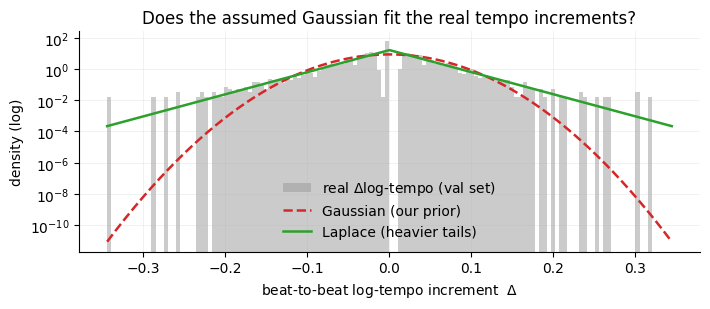

In [39]:
# The "big tempo jump" threshold for the tail statistic, owned HERE rather than buried in the diagnostic
# (the reading below quotes this exact number): |Delta log-tempo| > 0.2, i.e. exp(0.2)-1 ~ a 22%
# beat-to-beat tempo change. In log-tempo it is a fixed additive step, so it is tempo-relative (see above).
tempo_fit = plot_tempo_increment_fit(big_jump=0.2)   # nblib/diagnostics.py -- real Δlog-tempo vs assumed Gaussian

*Reading the plot.* The Gaussian random walk is an **assumption**, and the data is allowed to reject it — so we check rather than assert (the honest replacement for a hand-drawn "watch $\sigma_t$ widen" cartoon). On the log-$y$ axis the fitted Gaussian (red) is wrong in two directions at once: too fat in the shoulders and far too thin in the tails, missing *both* the sharp spike of near-zero increments (steady tempo) and the heavy tails (occasional abrupt tempo changes). A **Laplace** — the heavier-tailed law of the `madmom` lineage's exponential tempo transition — hugs both features; the Gaussian assigns a real $|\Delta| > 0.2$ tempo jump a probability more than $100\times$ too small (see the printout). One might hope the Gaussian's *data-conditioned* scale $\sigma_t$ (§1.4) rescues it by mimicking heavy tails frame-to-frame; the **normalized-residual test** in `tempo_increment_law.ipynb` settles that — it does not. So we **adopt the Laplace** in what follows (its Laplace–Laplace KL is equally closed-form, §4.1). The one honest caveat: on our beat data the switch is roughly *score-neutral*, so we make it for **fidelity to the measured increment law**, not a metric gain.

**Phase — wrapped Cauchy around the deterministic advance.** Phase advances deterministically by the previous tempo, $\mu_t^p = \phi_{t-1}+e^{\dot\phi_{t-1}}$, as in the bar-pointer lineage (Whiteley, Cemgil & Godsill, 2006; the particle-filter extension; Krebs et al.'s tempo-tied discretization). Two modifications: we decouple phase from meter entirely — phase sweeps a fixed circle $[0,2\pi)$ regardless of meter, with meter instead inferred from the phase trajectory (Meter, below), rather than meter determining the bar length as in the original model — and we make the transition *stochastic* rather than a deterministic (Dirac-delta) update, since assuming zero positional uncertainty is unrealistic given expressive timing, annotation noise, and tempo-estimation error. We make that stochastic transition **heavy-tailed** — a wrapped Cauchy rather than the lineage's implicit von Mises — because real beat-microtiming residuals have heavy tails (checked against the data just below).
$$\phi_t \sim \mathrm{WC}(\mu_t^p, \rho_t^p), \qquad \mu_t^p = \phi_{t-1} + e^{\dot\phi_{t-1}} \bmod 2\pi, \qquad \rho_t^p = \frac{c_t^p}{1+c_t^p}, \quad c_t^p = \mathrm{softplus}(f_c(h_t)).$$
The learned concentration $\rho_t^p \in (0,1)$ — the mean resultant length — controls how tightly phase clusters around its predicted advance: $\rho\to 1$ is the deterministic (point-mass) advance, $\rho\to 0$ a uniform phase. Phase needs the previous phase and previous tempo — not the previous meter, and, like tempo, nothing from the current frame either.

In [ ]:
# Phase's transition is the mirror image of tempo's: here the MEAN is the substantive part --
# phase *integrates* the tempo into the deterministic bar-pointer advance. Both the advance and
# the concentration's positive map are package code, imported and shown:
from model.bar_pointer_vae import predicted_phase_mean
from model.latents import phase_concentration_from_score
import inspect
print(inspect.getsource(predicted_phase_mean))
print(inspect.getsource(phase_concentration_from_score))

# What the phase latent is, made concrete: phi in [0, 2*pi) is the position WITHIN the bar
# (0 = downbeat), and beats fall where phi crosses 2*pi*k/M. Rolling the advance deterministically
# at a steady 120 BPM shows it doing exactly one job -- sweeping [0, 2*pi) once per bar:
omega = bpm_to_rad_per_frame(120.0)
frames_per_bar = TWO_PI / omega
log_tempo = torch.tensor(math.log(omega))
phase, first_wrap = torch.tensor(0.0), None
for frame in range(1, int(frames_per_bar) + 3):
    prev, phase = phase, predicted_phase_mean(phase, log_tempo)
    if phase < prev and first_wrap is None:
        first_wrap = frame
print(f"120 BPM in 4/4: advance {omega:.4f} rad/frame -> {frames_per_bar:.1f} frames/bar, "
      f"{frames_per_bar / 4:.1f} frames/beat")
print(f"deterministic rollout from phi=0 returns to the downbeat at frame {first_wrap} (~ frames/bar)")


11727 real phase residuals   excess kurtosis 9.3  (von Mises ~ 0)   fitted kappa 13
P(|rho| > 1.0) = 0.785% in the data, 0.056% under von Mises  ->  ~14x too thin in the far tail
corr(phase residual, tempo increment) = 0.95  ->  the SAME beat-timing deviation the tempo latent already models


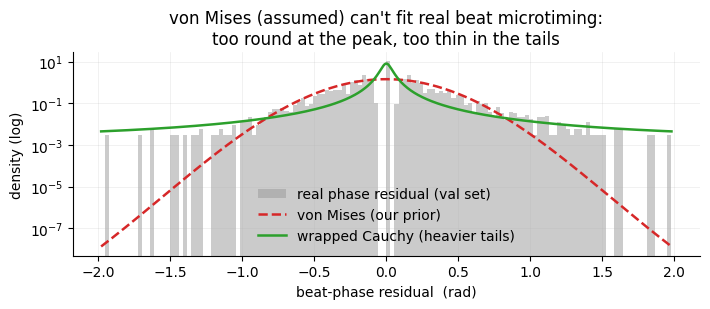

In [40]:
plot_phase_residual_fit()    # nblib/diagnostics.py -- real beat microtiming vs the assumed von Mises

*Reading the plot.* Same check as for tempo, now for the circular latent. The fitted von Mises (red) is wrong in the same two ways at once: too fat in the shoulders and too thin in *both* the sharp central spike (tight, near-metronomic beats) and the far tails (occasional large timing deviations) — beyond $|\rho|\approx 1$ rad it is ~14× too thin, and the residual's excess kurtosis is $\approx 9$ (a von Mises is $\approx 0$). A heavier-tailed circular law (wrapped Cauchy, green) hugs the tails far better, so — exactly as we adopted the Laplace for tempo — **we adopt the wrapped Cauchy for phase in what follows** (its KL is closed-form and Bessel-free, §4.3; its inverse-CDF sampler is trivially reparameterized, §5).

Two honest caveats. *First,* this is a **fidelity/robustness swap, not a clean fit win:** by raw held-out NLL the two are within noise — wrapped Cauchy over-corrects (too fat in the shoulders), so its far-tail gain and shoulder loss roughly cancel, and the comparison is quantization-confounded anyway. We make the switch to match the *measured* heavy tail, not for a metric gain — the same stance, and the same honesty, as the Laplace tempo. (The trade it carries into training: WC's inverse-CDF sample gives a plain-autograd reparameterization — no implicit-reparameterization trick, unlike von Mises — but its *scale* gradient is higher-variance; the low-variance concentration signal comes from the closed-form KL, §4.3.) *Second,* and deeper: this phase residual correlates $\approx 0.95$ with the §1.4 tempo increment — it is **the same beat-timing deviation**, because from beat annotations alone a late beat cannot be split into "the tempo changed" ($b$) versus "the beat was played expressively late" ($\rho$). The model carries **two** noise knobs, one per latent, for **one** observable, and both inherit the same heavy tails — which is exactly why we give both the heavy-tailed law.

**Meter — categorical with a learned, phase-aware transition.** A meter switch is triggered by a bar-boundary crossing, so meter depends on the previous meter and the phases that reveal whether a boundary was crossed, $p(m_t\mid m_{t-1},\phi_t,\phi_{t-1})$ — as in the bar-pointer lineage (Whiteley, Cemgil & Godsill, 2006; Krebs, Böck & Widmer's efficient state-space model and its `madmom` implementation, 2015). We modify both how the boundary is detected and how the transition is parameterized: rather than comparing discrete grid positions or a fixed, hand-set switch probability $\varepsilon$ (`madmom`), we detect a crossing from the *predicted* phase mean, $\phi_{t-1}+e^{\dot\phi_{t-1}}\ge 2\pi$ — which, unlike a check on the noisy sample $\phi_t$, doesn't depend on where the phase noise happens to land — and we learn the full transition matrix from a network rather than fixing it, since a constant switch rate can't adapt to musical context.
$$m_t \sim \mathrm{Cat}(\pi_t), \qquad \pi_t = \text{row } m_{t-1} \text{ of } \Pi_t, \qquad \Pi_t = \mathrm{softmax\text{-}rows}\big(f_m(m_{t-1}, \phi_t, \phi_{t-1}, h_t)\big).$$
This is the one exception: meter's transition needs $\phi_t$ itself, already sampled.


2978 real bars: 4->90.3%  3->9.5%   (model support {2,3,4}; 2 and 6/8 together 0.2% -- measurement dust)
118 songs: a fixed M=4 mislabels 14% of them (the 3/4 minority is real and identifiable)  ->  meter must be a latent
but 99.2% of songs keep ONE meter throughout; only 8/2853 bar-to-bar steps switch (0.3%)  ->  the empirical transition matrix is ~identity


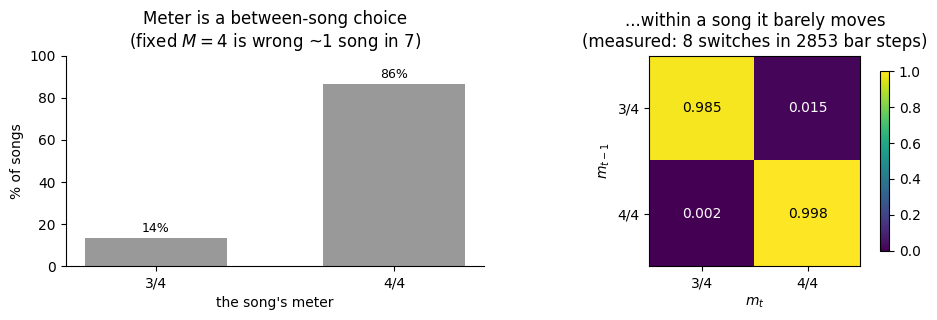

In [41]:
plot_meter_content_fit()   # nblib/diagnostics.py -- real per-song meter + measured bar-to-bar transitions (annotations only)


*Reading the plots.* Two honest facts about meter, neither visible in a hand-typed transition matrix. **Left:** meter is overwhelmingly a *between-song* constant — about one song in seven is 3/4, a real and identifiable minority, so a fixed $M=4$ is simply wrong on those. That is exactly why meter has to be a *latent* and not a hardcoded constant; but the ~6:1 imbalance is also why the objective barely pays to encode it (the collapse we autopsy in §11.1). **Right:** the bar-to-bar transition matrix, *measured* from the very same annotations, is essentially the identity — a handful of switches in ~2,800 steps, and 99% of songs never change meter at all. The learned, phase-gated transition $f_m$ above has the right *form* (it *can* move mass off the diagonal at a bar boundary), but this data barely exercises it: within a song the honest transition matrix is the identity, not the switch-happy cartoon it replaces.

So $\dot\phi_t$ and $\phi_t$ each depend on last frame's state alone — neither needs the other's *current*-frame value, so they can be peeled in either order relative to each other. $m_t$ is the one that cannot go first or in the middle unconstrained: it needs $\phi_t$ already drawn, so it must be peeled **last**. We peel tempo, then phase, then meter — mirroring the order the pointer physically evolves in (tempo is set, it pushes phase forward, and the resulting phase is what tells meter whether a bar just wrapped) — though phase-before-tempo would work exactly as well; the only *forced* constraint is meter last.

### 1.5 Factorizing the per-frame KL

**Step 1 — factorize the prior by chain rule (no assumptions).** Peel the three latents in the order just established — tempo, then phase, then meter — keeping every condition:

$$\begin{aligned}
p(\dot\phi_t, \phi_t, m_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) = \;& p(\dot\phi_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \\
&\times\; p(\phi_t \mid \dot\phi_t,\; \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \\
&\times\; p(m_t \mid \phi_t, \dot\phi_t,\; \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t).
\end{aligned}$$

Every factor carries the full previous frame $(\dot\phi_{t-1}, \phi_{t-1}, m_{t-1})$ and each earlier within-frame latent. This is exact — pure chain rule.

**Step 2 — apply the transitions above, then drop.** Using the realizations from §1.4:

1. **Tempo** reads neither $\phi_{t-1}$ nor $m_{t-1}$:
$$p(\dot\phi_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \;\longrightarrow\; p(\dot\phi_t \mid \dot\phi_{t-1}, h_t).$$
2. **Phase** advances the previous phase by the previous tempo, so it drops the current tempo $\dot\phi_t$ and the meter $m_{t-1}$:
$$p(\phi_t \mid \dot\phi_t, \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \;\longrightarrow\; p(\phi_t \mid \phi_{t-1}, \dot\phi_{t-1}, h_t).$$
3. **Meter**'s transition is a network of $m_{t-1}$ and the two phases, not the tempo:
$$p(m_t \mid \phi_t, \dot\phi_t, \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \;\longrightarrow\; p(m_t \mid m_{t-1}, \phi_t, \phi_{t-1}, h_t).$$

Substituting, the prior's per-frame transition factorizes as

$$p(z_t \mid z_{t-1}, h_t) = \underbrace{p(\dot\phi_t \mid \dot\phi_{t-1}, h_t)}_{\text{tempo}}\; \underbrace{p(\phi_t \mid \phi_{t-1}, \dot\phi_{t-1}, h_t)}_{\text{phase}}\; \underbrace{p(m_t \mid m_{t-1}, \phi_t, \phi_{t-1}, h_t)}_{\text{meter}}. \tag{1'}$$

The one dependence that survives *within* the frame is the meter's on the current phase $\phi_t$ — the wrinkle that makes the meter term special below.

**Step 3 — the posterior is mean-field over the same three latents.** The encoder emits all three factors' parameters from one shared per-frame context $(\dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, b_t, h_t)$, with no within-frame coupling:

$$q(\dot\phi_t, \phi_t, m_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, b_t, h_t) = q(\dot\phi_t)\, q(\phi_t)\, q(m_t),$$

writing $q(\dot\phi_t), q(\phi_t), q(m_t)$ as shorthand — each still conditions on the full $(\dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, b_t, h_t)$. Note the asymmetry this sets up: the posterior meter factor $q(m_t)$ has no $\phi_t$, but the prior meter factor keeps it.

**Step 4 — write the KL as an expectation and substitute both products.** By definition, the expectation runs over the joint posterior (integrals over $\dot\phi_t, \phi_t$ and a sum over $m_t$):

$$\begin{aligned}
&D_{\mathrm{KL}}\!\left(q(\dot\phi_t, \phi_t, m_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, b_t, h_t)\,\middle\|\,p(\dot\phi_t, \phi_t, m_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t)\right) \\
&\qquad = \mathbb{E}_{q(\dot\phi_t)\,q(\phi_t)\,q(m_t)}\!\left[\log\frac{q(\dot\phi_t)\,q(\phi_t)\,q(m_t)}{p(\dot\phi_t\mid \dot\phi_{t-1}, h_t)\,p(\phi_t\mid \phi_{t-1}, \dot\phi_{t-1}, h_t)\,p(m_t\mid m_{t-1}, \phi_t, \phi_{t-1}, h_t)}\right].
\end{aligned}$$

**Step 5 — split the log of a product into a sum of log-ratios** ($\log\frac{ABC}{DEF} = \log\frac{A}{D}+\log\frac{B}{E}+\log\frac{C}{F}$):

$$= \mathbb{E}_{q(\dot\phi_t)\,q(\phi_t)\,q(m_t)}\!\left[\log\frac{q(\dot\phi_t)}{p(\dot\phi_t\mid \dot\phi_{t-1}, h_t)} + \log\frac{q(\phi_t)}{p(\phi_t\mid \phi_{t-1}, \dot\phi_{t-1}, h_t)} + \log\frac{q(m_t)}{p(m_t\mid m_{t-1}, \phi_t, \phi_{t-1}, h_t)}\right].$$

**Step 6 — distribute the expectation** (linearity), and use $\mathbb{E}_{q(\dot\phi_t)q(\phi_t)q(m_t)} = \mathbb{E}_{q(\dot\phi_t)}\mathbb{E}_{q(\phi_t)}\mathbb{E}_{q(m_t)}$ (fully factorized $q$), so any factor whose variable is absent from an integrand integrates/sums to $1$:

$$= \underbrace{\mathbb{E}_{q(\dot\phi_t)q(\phi_t)q(m_t)}\!\left[\log\tfrac{q(\dot\phi_t)}{p(\dot\phi_t\mid \dot\phi_{t-1}, h_t)}\right]}_{\text{tempo}} + \underbrace{\mathbb{E}_{q(\dot\phi_t)q(\phi_t)q(m_t)}\!\left[\log\tfrac{q(\phi_t)}{p(\phi_t\mid \phi_{t-1}, \dot\phi_{t-1}, h_t)}\right]}_{\text{phase}} + \underbrace{\mathbb{E}_{q(\dot\phi_t)q(\phi_t)q(m_t)}\!\left[\log\tfrac{q(m_t)}{p(m_t\mid m_{t-1}, \phi_t, \phi_{t-1}, h_t)}\right]}_{\text{meter}}.$$

**Step 7a — tempo.** The integrand depends on $\dot\phi_t$ only, so $q(\phi_t)$ and $q(m_t)$ sum/integrate to $1$:

$$\mathbb{E}_{q(\dot\phi_t)q(\phi_t)q(m_t)}\!\left[\log\frac{q(\dot\phi_t)}{p(\dot\phi_t\mid \dot\phi_{t-1}, h_t)}\right] = \mathbb{E}_{q(\dot\phi_t)}\!\left[\log\frac{q(\dot\phi_t)}{p(\dot\phi_t\mid \dot\phi_{t-1}, h_t)}\right] = D_{\mathrm{KL}}\!\left(q(\dot\phi_t)\,\middle\|\,p(\dot\phi_t\mid \dot\phi_{t-1}, h_t)\right).$$

**Step 7b — phase.** The integrand depends on $\phi_t$ only — its prior reads $\phi_{t-1}, \dot\phi_{t-1}$ (fixed), **not** the current $\dot\phi_t$ or $m_t$ (Step 2.2) — so $q(\dot\phi_t)$ and $q(m_t)$ drop:

$$\mathbb{E}_{q(\dot\phi_t)q(\phi_t)q(m_t)}\!\left[\log\frac{q(\phi_t)}{p(\phi_t\mid \phi_{t-1}, \dot\phi_{t-1}, h_t)}\right] = \mathbb{E}_{q(\phi_t)}\!\left[\log\frac{q(\phi_t)}{p(\phi_t\mid \phi_{t-1}, \dot\phi_{t-1}, h_t)}\right] = D_{\mathrm{KL}}\!\left(q(\phi_t)\,\middle\|\,p(\phi_t\mid \phi_{t-1}, \dot\phi_{t-1}, h_t)\right).$$

**Step 7c — meter (the one that is different).** Here the integrand depends on $m_t$ **and** $\phi_t$, because the meter prior conditions on the current phase $\phi_t$ (Step 2.3). Only $q(\dot\phi_t)$ is absent and integrates away; both $q(\phi_t)$ and $q(m_t)$ stay:

$$\mathbb{E}_{q(\dot\phi_t)q(\phi_t)q(m_t)}\!\left[\log\frac{q(m_t)}{p(m_t\mid m_{t-1}, \phi_t, \phi_{t-1}, h_t)}\right] = \mathbb{E}_{q(\phi_t)}\,\mathbb{E}_{q(m_t)}\!\left[\log\frac{q(m_t)}{p(m_t\mid m_{t-1}, \phi_t, \phi_{t-1}, h_t)}\right].$$

Do the *inner* sum over $m_t$ at a fixed $\phi_t$ — that is a categorical KL — but the *outer* $\mathbb{E}_{q(\phi_t)}$ has nowhere to go, since the KL it wraps still depends on $\phi_t$:

$$= \mathbb{E}_{q(\phi_t)}\!\left[D_{\mathrm{KL}}\!\left(q(m_t)\,\middle\|\,p(m_t\mid m_{t-1}, \phi_t, \phi_{t-1}, h_t)\right)\right].$$

This is exactly why the meter term is *not* a plain marginal KL: the factorization of $q$ lets the expectation split into a product, but the coupling lives in the **prior** $p(m_t\mid\dots,\phi_t,\dots)$ (Step 2.3), which no factorization of $q$ can undo.

**Step 8 — assemble.**

$$\begin{aligned}
&D_{\mathrm{KL}}\!\left(q(\dot\phi_t, \phi_t, m_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, b_t, h_t)\,\middle\|\,p(\dot\phi_t, \phi_t, m_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t)\right) \\
&\qquad = D_{\mathrm{KL}}\!\left(q(\dot\phi_t)\,\middle\|\,p(\dot\phi_t\mid \dot\phi_{t-1}, h_t)\right) + D_{\mathrm{KL}}\!\left(q(\phi_t)\,\middle\|\,p(\phi_t\mid \phi_{t-1}, \dot\phi_{t-1}, h_t)\right) \\
&\qquad\quad + \mathbb{E}_{q(\phi_t)}\!\left[D_{\mathrm{KL}}\!\left(q(m_t)\,\middle\|\,p(m_t\mid m_{t-1}, \phi_t, \phi_{t-1}, h_t)\right)\right].
\end{aligned}$$

In the single-sample SGVB rollout the surviving $\mathbb{E}_{q(\phi_t)}$ is estimated at the sampled $\phi_t$ — i.e. evaluate the meter KL *after* drawing $\phi_t$. These three pieces are the tempo (Laplace), phase (wrapped Cauchy), and meter (Categorical) KLs implemented in §4.

---

## 2. The generative story

Music has a nested clock structure: bars contain beats, beats recur at the tempo. The *bar pointer* idea (Whiteley, Cemgil & Godsill, 2006) models this with a single pointer that sweeps once around a circle per **bar** and wraps at the downbeat. We keep the pointer's full state — meter, phase, tempo — as three separate random variables per frame, each with a distributional form matched to its geometry, and learn the whole thing as a sequential VAE.

**Observed data.** Time is discretized into frames (hop 256 samples at 22,050 Hz => 86.13 frames/s). For each frame $t = 1, \dots, T$ we observe a binary event vector $b_t = (b^{beat}_t, b^{down}_t) \in \{0, 1\}^2$, and a conditioning feature vector $h_t \in \mathbb{R}^{512}$ from a frozen audio frontend.

**Latent state**, per frame, $z_t = (\dot\phi_t, \phi_t, m_t)$:

| symbol | space | meaning | family |
|---|---|---|---|
| $\dot\phi_t$ | $\mathbb{R}$ | log-tempo: log of the bar-phase advance per frame | Laplace (random walk) |
| $\phi_t$ | $[0, 2\pi)$ | bar phase: 0 = downbeat, sweeps once per bar | wrapped Cauchy |
| $m_t$ | $\{1, \dots, K\}$ | meter hypothesis ($k$ = "$k$ beats per bar") | Categorical |

The actual (positive) tempo is $\omega_t = e^{\dot\phi_t}$ rad/frame — log-Laplace, since its log is Laplace.

**Deriving the per-frame transition.** We derive $p(z_t \mid z_{t-1}, h_t)$ from the raw chain rule, with no assumptions yet, peeling the three latents in the order they're generated — tempo, then phase, then meter:

$$\begin{aligned}
p(\dot\phi_t, \phi_t, m_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) = \;& p(\dot\phi_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \\
&\times\; p(\phi_t \mid \dot\phi_t,\; \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \\
&\times\; p(m_t \mid \phi_t, \dot\phi_t,\; \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t).
\end{aligned}$$

This is exact — pure chain rule; every factor still carries the full previous frame and each earlier within-frame latent. Now say how each transition is actually realized, and drop what it doesn't need:

1. **Tempo — log-Laplace random walk.** Mean is the previous tempo $\dot\phi_{t-1}$, scale a per-frame function of $h_t$; it reads neither $\phi_{t-1}$ nor $m_{t-1}$:
$$\dot\phi_t \sim \mathrm{Laplace}(\dot\phi_{t-1}, b_t), \quad b_t = \mathrm{softplus}(f_b(h_t)), \qquad p(\dot\phi_t \mid \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \;\longrightarrow\; p(\dot\phi_t \mid \dot\phi_{t-1}, h_t).$$
2. **Phase — wrapped Cauchy around the deterministic advance.** Mean is the bar-pointer advance $\phi_{t-1} + e^{\dot\phi_{t-1}}$: it advances the previous phase by the previous tempo, so it drops the current tempo $\dot\phi_t$ and the meter $m_{t-1}$ — and, since the pointer always sweeps the same circle regardless of how events are read off it, it never conditions on meter at all:
$$\phi_t \sim \mathrm{WC}(\mu_t^p, \rho_t^p), \quad \mu_t^p = \phi_{t-1} + e^{\dot\phi_{t-1}} \bmod 2\pi, \quad \rho_t^p = c_t^p/(1+c_t^p),\ c_t^p = \mathrm{softplus}(f_c(h_t)), \qquad p(\phi_t \mid \dot\phi_t, \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \;\longrightarrow\; p(\phi_t \mid \phi_{t-1}, \dot\phi_{t-1}, h_t).$$
3. **Meter — categorical with a learned, phase-aware transition.** Meter should only switch at a bar boundary — i.e. when the pointer wraps, visible from $(\phi_{t-1}, \phi_t)$ — so its transition matrix reads $m_{t-1}$ and *both* phases, not the tempo:
$$m_t \sim \mathrm{Cat}(\pi_t), \quad \pi_t = \text{row } m_{t-1} \text{ of } \Pi_t, \quad \Pi_t = \mathrm{softmax\text{-}rows}\big(f_m(m_{t-1}, \phi_t, \phi_{t-1}, h_t)\big), \qquad p(m_t \mid \phi_t, \dot\phi_t, \dot\phi_{t-1}, \phi_{t-1}, m_{t-1}, h_t) \;\longrightarrow\; p(m_t \mid m_{t-1}, \phi_t, \phi_{t-1}, h_t).$$

Substituting, the per-frame transition factorizes as
$$p(z_t \mid z_{t-1}, h_t) = \underbrace{p(\dot\phi_t \mid \dot\phi_{t-1}, h_t)}_{\text{tempo}}\; \underbrace{p(\phi_t \mid \phi_{t-1}, \dot\phi_{t-1}, h_t)}_{\text{phase}}\; \underbrace{p(m_t \mid m_{t-1}, \phi_t, \phi_{t-1}, h_t)}_{\text{meter}}. \tag{1'}$$

The one dependence that survives *within* the frame is the meter's on the current phase $\phi_t$ — this is exactly what forces an extra expectation to survive the ELBO's per-frame KL split (§1.5).

**Factorization.** With $z_t = (\dot\phi_t, \phi_t, m_t)$ and eq. (1') as the per-frame transition, the full sequence factorizes (chain rule, first-order state Markov, local emission — re-derived from scratch in §1.1) as
$$p(b_{1:T}, z_{1:T} \mid h_{1:T}) = p(z_1 \mid h_1)\, p(b_1 \mid z_1) \prod_{t=2}^{T} p(z_t \mid z_{t-1}, h_t)\, p(b_t \mid z_t). \tag{1}$$

**Emission — Bernoulli from the latent state only.**
$$p(b_t \mid z_t) = \prod_{c \in \{\text{beat},\,\text{down}\}} \mathrm{Bernoulli}\big(b_t^c \mid \sigma(g_\theta(z_t)_c)\big), \qquad g_\theta : (\cos\phi_t, \sin\phi_t, \dot\phi_t, m_t) \mapsto \mathbb{R}^2.$$
$g_\theta$ reads **only** $z_t$, never $h_t$: if the decoder could see the audio directly it could reconstruct events while ignoring the latents, and the whole state-space structure would be decorative.


## 3. The inference model

We approximate the posterior with a filtering-shaped variational family:

$$ q(z_{1:T} | b, h) = q(z_1 | b, h) \prod_{t=2}^{T} q(z_t | z_{t-1}, b, h) $$

Each factor is a product of the three latent families:

$$ q(z_t | z_{t-1}, b, h) = \mathrm{Laplace}(s_t | \mu_s, b_s)\, \mathrm{WC}(\phi_t | \mu_\phi, \rho_\phi)\, \mathrm{Cat}(m_t | \pi_q) $$

### 4.1 Laplace KL (Tempo)

$$ D_{KL}\big(\mathrm{Laplace}(\mu_q, b_q)\,\|\,\mathrm{Laplace}(\mu_p, b_p)\big) = \log\frac{b_p}{b_q} + \frac{b_q\, e^{-|\mu_q-\mu_p|/b_q} + |\mu_q-\mu_p|}{b_p} - 1 $$

In [ ]:
from model.latents import kl_between_laplaces, kl_between_normals

# Verification oracle: torch's registered Laplace/Laplace (and Normal/Normal) KL.
loc_q, scale_q = torch.randn(1000), torch.rand(1000) + 0.1
loc_p, scale_p = torch.randn(1000), torch.rand(1000) + 0.1
ours_laplace = kl_between_laplaces(loc_q, scale_q, loc_p, scale_p)
oracle_laplace = kl_divergence(Laplace(loc_q, scale_q), Laplace(loc_p, scale_p))
ours_normal = kl_between_normals(loc_q, scale_q, loc_p, scale_p)
oracle_normal = kl_divergence(Normal(loc_q, scale_q), Normal(loc_p, scale_p))
assert torch.allclose(ours_laplace, oracle_laplace, atol=1e-5), "Laplace KL disagrees with torch"
assert torch.allclose(ours_normal, oracle_normal, atol=1e-6), "Gaussian KL disagrees with torch"
print(f"Laplace KL matches torch.distributions on 1000 random pairs "
      f"(max abs diff {float((ours_laplace - oracle_laplace).abs().max()):.2e}); "
      f"Gaussian KL also verified (kept for the Section 1.4 comparison).")


### 4.2 Categorical (the meter term)

For discrete $q, p$ over $K$ classes the expectation is a sum — the definition *is* the closed form:

$$
D_{\mathrm{KL}}\big(\mathrm{Cat}(\pi^q) \,\|\, \mathrm{Cat}(\pi^p)\big)
= \sum_{k=1}^{K} \pi^q_k \left(\log \pi^q_k - \log \pi^p_k\right).
\tag{11}
$$

We implement it on **log-probabilities** (numerically safer than dividing probabilities).

In [ ]:
from model.latents import kl_between_categoricals

logits_q, logits_p = torch.randn(1000, 4), torch.randn(1000, 4)
ours = kl_between_categoricals(F.log_softmax(logits_q, -1), F.log_softmax(logits_p, -1))
oracle = kl_divergence(Categorical(logits=logits_q), Categorical(logits=logits_p))
assert torch.allclose(ours, oracle, atol=1e-6), "Categorical KL disagrees with torch"
print(f"Categorical KL matches torch.distributions (max abs diff {float((ours - oracle).abs().max()):.2e})")


### 4.3 Wrapped Cauchy KL (Phase)

$$ D_{KL}\big(\mathrm{WC}(\mu_q, \rho_q)\,\|\,\mathrm{WC}(\mu_p, \rho_p)\big) = \log \frac{1 + (\rho_q\rho_p)^2 - 2\,\rho_q\rho_p\cos(\mu_q - \mu_p)}{(1 - \rho_q^2)(1 - \rho_p^2)} \tag{12}$$

Closed form and **Bessel-free** — cheaper than the von Mises KL it replaces — where $\rho = c/(1+c) \in (0,1)$ is the mean resultant length. torch has no wrapped-Cauchy law, so we verify the closed form against a direct numerical integral of $\int q\,(\log q - \log p)$ (below).

In [ ]:
from model.latents import concentration_to_rho, kl_between_wrapped_cauchy, wrapped_cauchy_log_prob

# Verification: torch has no wrapped Cauchy law, so check the closed form against a direct
# numerical integral (dense quadrature; the density integrates to 1, so no sampling variance).
angle_grid = torch.linspace(0.0, TWO_PI, 4001)[:-1]
d_theta = TWO_PI / 4000.0
for mean_q_val, conc_q_val, mean_p_val, conc_p_val in [(0.3, 2.0, 1.0, 5.0), (2.9, 20.0, 3.4, 8.0), (0.0, 0.5, 3.1, 0.5)]:
    log_q = wrapped_cauchy_log_prob(angle_grid, torch.tensor(mean_q_val), torch.tensor(conc_q_val))
    log_p = wrapped_cauchy_log_prob(angle_grid, torch.tensor(mean_p_val), torch.tensor(conc_p_val))
    numerical_kl = float((log_q.exp() * (log_q - log_p)).sum() * d_theta)
    closed_form_kl = float(kl_between_wrapped_cauchy(
        torch.tensor(mean_q_val), torch.tensor(conc_q_val), torch.tensor(mean_p_val), torch.tensor(conc_p_val)))
    rho_q_val, rho_p_val = conc_q_val / (1 + conc_q_val), conc_p_val / (1 + conc_p_val)
    print(f"WC KL  q=WC({mean_q_val}, rho={rho_q_val:.3f}) p=WC({mean_p_val}, rho={rho_p_val:.3f}):  "
          f"closed form {closed_form_kl:.4f}  vs  numerical {numerical_kl:.4f}")
    assert abs(numerical_kl - closed_form_kl) < 1e-3


## 5. Reparameterized Sampling

**Location-scale (tempo, Laplace):** $s = \mu + b\,\varepsilon$ with $\varepsilon \sim \mathrm{Laplace}(0, 1)$ — a differentiable transform of parameter-free noise (torch's `rsample`); the gradient flows through $\mu$ and $b$ directly.

**Wrapped Cauchy (phase):** the phase family is *also* just a differentiable transform of parameter-free noise — wrap a linear Cauchy through its inverse CDF:

$$ \phi = \big(\mu + \gamma\,\tan(\pi(u - \tfrac{1}{2}))\big) \bmod 2\pi, \qquad \gamma = -\log\rho, \qquad u \sim \mathrm{Uniform}(0,1). $$

So plain autograd reparameterizes it through **both** $\mu$ and the concentration (via $\rho,\gamma$) — **no implicit-reparameterization trick is needed** (the von Mises arm *does* need one, since it has no closed-form inverse CDF). The one cost: because the Cauchy step is heavy-tailed, the *pathwise* gradient w.r.t. the scale is higher-variance than a light-tailed reparameterization — but the low-variance signal for the concentration comes from the closed-form KL (§4.3), and the $\mu$ gradient is bounded.

In [ ]:
from model.latents import sample_wrapped_cauchy
import inspect; print(inspect.getsource(sample_wrapped_cauchy))


In [ ]:
# Verify the reparameterized sampler reproduces the wrapped Cauchy law: for mean 0 the mean resultant
# length E[cos phi] must equal rho = c/(1+c) (the wrapped Cauchy characteristic function). This checks the
# *draw*; the gradient itself flows by plain autograd, since phi is a differentiable transform of U(0,1).
set_all_seeds(0)
print(f"{'concentration':>13} {'empirical E[cos]':>18} {'rho = c/(1+c)':>15}")
for concentration_value in [0.5, 2.0, 8.0]:
    samples = sample_wrapped_cauchy(torch.zeros(2_000_000), torch.full((2_000_000,), concentration_value))
    empirical_resultant = float(torch.cos(samples).mean())
    rho = concentration_value / (1.0 + concentration_value)
    print(f"{concentration_value:>13.1f} {empirical_resultant:>18.4f} {rho:>15.4f}")
    assert abs(empirical_resultant - rho) < 0.005
print("wrapped Cauchy sampler verified (matches its mean resultant length); "
      "gradients flow through mean and concentration by plain autograd")

 kappa  implicit-reparam grad   analytic A-prime


   0.5                 0.4575             0.4562


   2.0                 0.1645             0.1642


   8.0                 0.0085             0.0084
implicit reparameterization gradient verified


## 6. Data: cached frozen-frontend features + beat annotations

The conditioning features $\mathbf{h}_{1:T}$ come from **Beat This** (Foscarin et al., 2024), a published
transformer beat tracker, used here as a *frozen* feature extractor: its 512-dim penultimate activations were
computed once per song and cached to disk together with the frame-level beat/downbeat annotations
(this repository's `data/feature_extractor.py` builds the cache from the vendored
`external/beat_this` submodule — reused, not reimplemented). The notebook consumes the cache, so it runs
without audio or the frontend in memory.

Being explicit about the division of labor: the frozen frontend solves the *perceptual* problem (audio →
"how beat-like is this frame"). What this notebook studies is the **state-space layer on top** — whether a
structured latent pointer can be *inferred variationally* so that beats, downbeats, tempo and meter come out
of one coherent trajectory.

In [ ]:
# Experiment-scale constants (one place, so both experiments run identically).
# VBPM_NOTEBOOK_SMOKE=1 shrinks everything for a fast syntax/shape check of the whole notebook.
SMOKE_MODE = bool(os.environ.get("VBPM_NOTEBOOK_SMOKE"))

HIDDEN_SIZE = 64
NUM_METERS = 4                        # meter hypotheses: 1..4 beats per bar

NUM_TRAIN_SONGS = 24 if SMOKE_MODE else 200
NUM_VAL_SONGS = 4 if SMOKE_MODE else 16
CROP_LENGTH_FRAMES = 256 if SMOKE_MODE else 1024   # ~12 s crops: tempo drift must exist inside the window
BATCH_SIZE = 8 if SMOKE_MODE else 32               # batch is ~free at these crop lengths (launch-bound loop)
NUM_TRAINING_STEPS = 30 if SMOKE_MODE else 700
LOG_EVERY_STEPS = 15 if SMOKE_MODE else 100
LEARNING_RATE = 1e-3
GRADIENT_CLIP_NORM = 5.0
EVAL_MAX_FRAMES = 512 if SMOKE_MODE else 1600   # ~18.6 s per song at full scale

train_feature_dir = next(p for p in ("cache/acts/bt_train_rich", "../cache/acts/bt_train_rich") if os.path.isdir(p))
val_feature_dir = train_feature_dir.replace("bt_train_rich", "bt_val_rich")
print(f"feature cache: {train_feature_dir} | smoke mode: {SMOKE_MODE}")

feature cache: ../cache/acts/bt_train_rich | smoke mode: False


In [ ]:
train_songs = load_cached_songs(train_feature_dir, NUM_TRAIN_SONGS, selection_seed=1)
validation_songs = load_cached_songs(val_feature_dir, NUM_VAL_SONGS, selection_seed=2)
print(f"loaded {len(train_songs)} training songs, {len(validation_songs)} validation songs; "
      f"feature dim {train_songs[0].features.shape[1]}")

loaded 200 training songs, 16 validation songs; feature dim 512


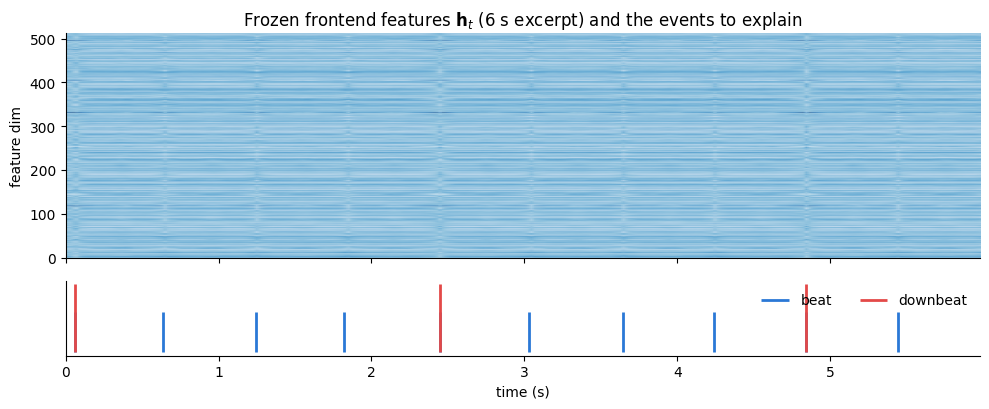

In [38]:
plot_raw_material(validation_songs[0])   # nblib/plotting.py -- 6 s of frontend features + annotated events

## 7. The model as one module

One `nn.Module` holds every network in equations (1)–(6). The map from math to attribute:

| equation | object | attribute |
|---|---|---|
| (2) prior tempo scale $b_t = \mathrm{softplus}(f_b(\mathbf{h})_t)$ (Laplace) | linear head on prior context | `prior_tempo_std_head` |
| (3) prior phase concentration $\rho^p_t = c/(1+c)$ (wrapped Cauchy) | linear head on prior context | `prior_phase_concentration_head` |
| (4) meter transition matrix $\Pi_t$ | MLP $\to K \times K$ softmax rows | `meter_transition_network` |
| (5) decoder $g_\theta(\mathbf{z}_t)$ | MLP, input = latent feature only | `event_decoder` |
| (6') posterior params for all 3 latents | Transformer context + shared head | `posterior_encoder`, `posterior_parameter_head` |
| $p(\mathbf{z}_1 \mid \mathbf{h})$ initial prior | MLP on pooled prior context | `initial_prior_head` |

Two representation choices worth flagging because they prevent silent bugs:

* **Angles are emitted as $(\cos, \sin)$ pairs** and recovered with `atan2` — a network that output a raw
  angle would face a discontinuity at the $0/2\pi$ wrap.
* **The sampled previous state** $\text{feature}(\mathbf{z}_{t-1}) = (\cos\varphi, \sin\varphi, \dot{\phi}, m)$ feeds
  both the posterior head (making $q$ autoregressive) and the decoder — the same vector, built once.

In [ ]:
# The model derived above is implemented in model/bar_pointer_vae.py (with the latent families in
# model/latents.py and the filter deployment in model/particle_filter.py) and IMPORTED -- the
# notebook no longer carries a second copy. The map from math to attribute is in the class
# docstring; inspect any piece with ??VariationalBarPointerModel in Jupyter.
from model.bar_pointer_vae import (RolloutResult, TransformerContext, ParametricPointerEmission,
                                   VariationalBarPointerModel, predicted_phase_mean)

model_summary = VariationalBarPointerModel(feature_dim=FEATURE_DIM, hidden_size=HIDDEN_SIZE,
                                           num_meters=NUM_METERS)
print(f"parameters: {sum(p.numel() for p in model_summary.parameters()):,}")
print("emission (default parametric):", model_summary.event_decoder)
del model_summary


## 8. The training objective: $-\mathcal{L}$, term by term

The training loss is the **negative ELBO of eq. (8)**, estimated with the rollout's single sample path, in
nats per sequence (summed over frames, averaged over the batch):

| ELBO term | estimator | code |
|---|---|---|
| $-\sum_t \mathbb{E}_q[\log p(\mathbf{b}_t \mid \mathbf{z}_t)]$ | binary cross-entropy of the decoder logits at the sampled $\hat{\mathbf{z}}_t$, summed over frames and both channels | `reconstruction_nats` |
| $D_{\mathrm{KL}}$ tempo stream (eq. 9, all $t$) | closed form (10) at the sampled path | `rollout.kl_tempo` |
| $D_{\mathrm{KL}}$ phase stream | closed form (12) at the sampled path | `rollout.kl_phase` |
| $D_{\mathrm{KL}}$ meter stream | closed form (11) at the sampled path | `rollout.kl_meter` |

No weighting anywhere: $\beta = 1$ on every KL, plain Bernoulli likelihood. This is the *pure* objective —
Experiment 1 trains on exactly this.

In [ ]:
# The objective of eq. (8) -- reconstruction + the three (floored) KLs + the auxiliary EMISSION
# terms (meter CE / sawtooth / tempo slope; each a likelihood on an observed quantity, so the
# objective stays a tempered ELBO) -- is implemented in losses.py and data/targets.py, imported:
from losses import negative_elbo_terms, auxiliary_emission_terms
from data.targets import crop_beats_per_bar_classes
import inspect; print(inspect.getsource(negative_elbo_terms))


## 9. Deployment: the geometric read-out, and how we score it

At inference time the decoder is thrown away. The point of the latent structure is that events fall out of
the **pointer geometry**:

* a **downbeat** is where the bar phase $\varphi_t$ completes a revolution (wraps $2\pi \to 0$);
* a **beat** is where the *beat phase* $M\varphi_t \bmod 2\pi$ wraps ($M$ = beats per bar).

The encoder runs with its event channels **zeroed** (at deployment nobody hands you the answers), in
deterministic mode (posterior means). Estimated times are scored against the annotations with `mir_eval`'s
standard beat F-measure (±70 ms tolerance).

**Leak controls.** A read-out can look alive for degenerate reasons, so every evaluation reports three
conditions: **real** (the song's own features), **shuffle** (another song's features — must collapse, or the
model is not using *this* audio), and **zero** (silence — must collapse, or the model learned an
input-independent metronome). We also track two *mechanism* diagnostics that catch failure modes the
F-measure hides: **phase coverage** (fraction of 16 phase-histogram bins the trajectory visits — a frozen
pointer scores low) and **rotation ratio** (total revolutions ÷ annotated bar count — a healthy pointer
scores ≈ 1).

## 10. A shared training harness

One function trains a model from scratch and records its trajectory; both experiments call it — the **only**
difference between them is the `sawtooth_weight` argument (0 = the pure negative ELBO of §8). The sawtooth
term itself is defined and explained in §12; the harness just adds it when its weight is nonzero. The meter
relaxation temperature anneals $1.0 \to 0.3$ over training.

In [ ]:
# The training harness is train.py's loop; the notebook keeps a thin wrapper with the same
# signature the experiment cells call (config-object plumbing hidden, experiment dials visible).
from config import load_config
from train import train as _train_from_config

def train_bar_pointer_model(sawtooth_weight=0.0, num_steps=NUM_TRAINING_STEPS, seed=0,
                            hybrid_alpha=1.0,
                            free_bits_nats_per_frame=0.0, transition_correction_scale=0.0,
                            prior_preserving_free_bits=False, meter_ce_weight=0.0,
                            tempo_slope_weight=0.0, decoder_input_mode="full",   # notebook experiments predate the parametric default
                            fixed_prior_scales=None):
    cfg = load_config()
    cfg.seed = seed
    cfg.model.hidden_size = HIDDEN_SIZE
    cfg.model.num_meters = NUM_METERS
    cfg.model.emission = decoder_input_mode
    cfg.model.transition_correction_scale = transition_correction_scale
    cfg.model.fixed_prior_scales = list(fixed_prior_scales) if fixed_prior_scales else None
    cfg.objective.sawtooth_weight = sawtooth_weight
    cfg.objective.hybrid_alpha = hybrid_alpha
    cfg.objective.tempo_slope_weight = tempo_slope_weight
    cfg.objective.meter_ce_weight = meter_ce_weight
    cfg.objective.free_bits_nats_per_frame = free_bits_nats_per_frame
    cfg.objective.prior_preserving_free_bits = prior_preserving_free_bits
    cfg.training.steps = num_steps
    cfg.training.batch_size = BATCH_SIZE
    cfg.training.crop_frames = CROP_LENGTH_FRAMES
    cfg.training.train_songs = NUM_TRAIN_SONGS
    cfg.training.val_songs = NUM_VAL_SONGS
    cfg.training.train_feature_dir = train_feature_dir
    cfg.training.val_feature_dir = val_feature_dir
    cfg.training.log_every_steps = LOG_EVERY_STEPS
    cfg.training.eval_max_frames = EVAL_MAX_FRAMES
    cfg.training.save_path = ""
    return _train_from_config(cfg)


## 11. Experiment 1 — the pure negative ELBO

Everything is now in place: a well-specified generative model, a matched variational family, exact
closed-form KLs, correct reparameterized gradients through all three latents. Train it on its own objective
and watch the three KL streams — in a healthy sequential VAE the phase stream should stay visibly positive
(the posterior must keep telling the prior *where in the bar* the music actually is).

In [ ]:
print("Experiment 1: pure negative ELBO (sawtooth_weight = 0)")
vanilla_model, vanilla_history = train_bar_pointer_model(sawtooth_weight=0.0)

Experiment 1: pure negative ELBO (sawtooth_weight = 0)


/home/sogang/mnt/db_2/anaconda3/envs/chart/lib/python3.10/site-packages/sympy/external/gmpy.py:138: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,


  step  100 | recon   38.49 | KL meter   0.13 phase    0.22 tempo  21.92 | deploy beat F 0.000 downbeat F 0.000


  step  200 | recon   36.92 | KL meter   0.02 phase    0.14 tempo   8.25 | deploy beat F 0.000 downbeat F 0.000


  step  300 | recon   33.14 | KL meter   0.24 phase    0.05 tempo  10.48 | deploy beat F 0.000 downbeat F 0.000


  step  400 | recon   40.32 | KL meter   0.02 phase    0.07 tempo   5.08 | deploy beat F 0.000 downbeat F 0.000


  step  500 | recon   36.14 | KL meter   0.06 phase    0.04 tempo  10.65 | deploy beat F 0.000 downbeat F 0.000


  step  600 | recon   34.45 | KL meter   0.02 phase    0.04 tempo   6.49 | deploy beat F 0.000 downbeat F 0.000


  step  700 | recon   39.39 | KL meter   0.04 phase    0.03 tempo   7.51 | deploy beat F 0.000 downbeat F 0.000


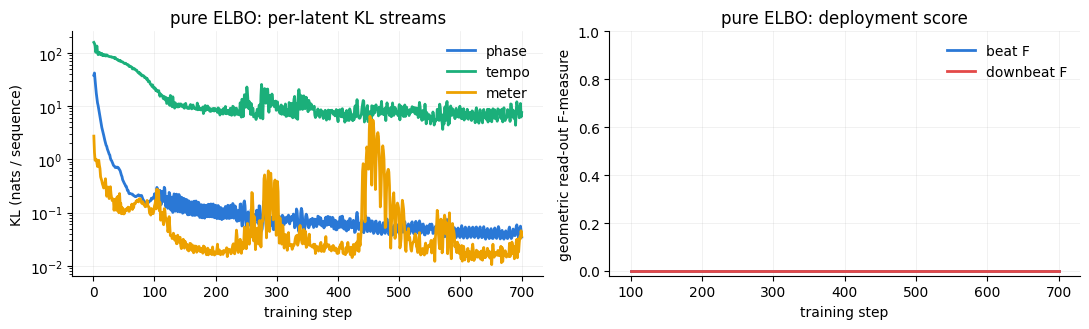

In [ ]:
plot_training_history(vanilla_history, "pure ELBO")

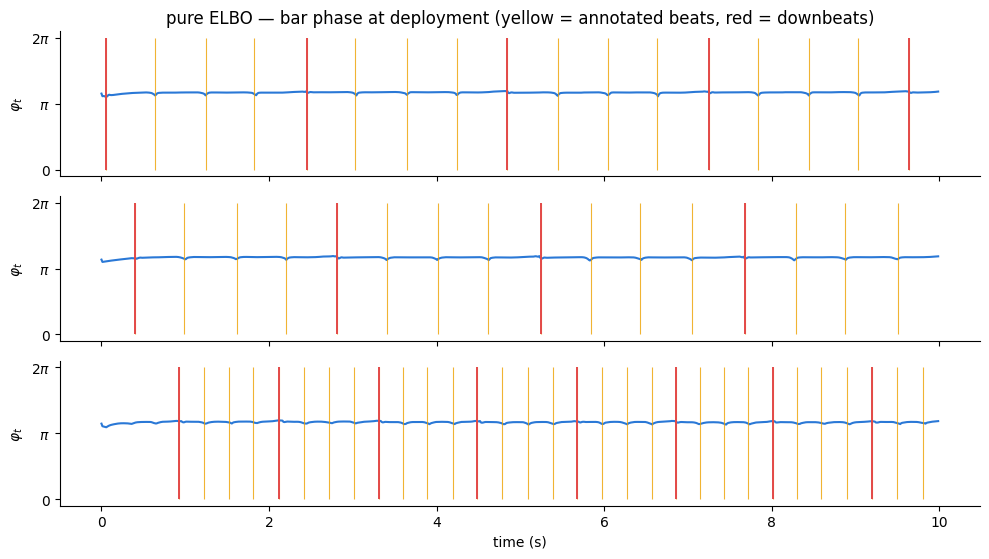


pure ELBO — geometric read-out on 16 validation songs:
  condition    beat F  downbeat F
  real          0.000       0.000
  shuffle       0.000       0.000
  zero          0.034       0.000
  mechanism (real): phase coverage 0.12, rotation ratio 0.00


In [ ]:
plot_phase_trajectories(vanilla_model, validation_songs, "pure ELBO")
print_leak_table(vanilla_model, validation_songs, "pure ELBO", EVAL_MAX_FRAMES)

### 11.1 Autopsy: posterior collapse

The pattern above is **posterior collapse**, and it has a specific anatomy here:

* **The phase KL stream falls to ≈ 0 nats.** By eq. (12), the KL is zero exactly when the posterior equals
  the prior at every frame ($\mu^q_t = \mu^p_t$, $\rho^q_t = \rho^p_t$). The encoder has stopped telling
  the dynamics anything about where the bar actually is: $q(\varphi_t \mid \cdot) = p(\varphi_t \mid \cdot)$.
* **The deployed pointer does not sweep.** Coverage and rotation ratio near zero mean the phase trajectory
  sits nearly frozen instead of rotating once per bar — with no informative posterior pulling it around the
  circle, the cheapest self-consistent configuration is a pointer that barely moves, with the tempo mean
  correspondingly meaningless.
* **The decoder still reconstructs *something*.** Reconstruction falls toward the base-rate entropy of the
  event channels: with the latents uninformative, the best the latent-only decoder can do is predict the
  average event probability every frame. (Beats occupy a few percent of frames, so even this "blind" solution
  scores decent nats — that observation is the key to §13.)

Two families of explanation are on the table, with very different consequences:

1. **An optimization failure.** The rotating solution is the better optimum, but gradient descent cannot find
   it (bad initialization, credit assignment through 256 sampled steps, the KL crushing the signal early).
   If so, optimizer-side tricks — KL warm-up, free bits, encoder dropout, longer training — should rescue it.
2. **The objective's actual preference.** The collapsed solution has *higher ELBO* than the rotating one, and
   the optimizer is doing its job perfectly. If so, no optimizer trick can help; the objective itself must be
   changed (or augmented).

These make opposite testable predictions. After Experiment 2 hands us a healthy *rotating* set of weights for
the **same architecture**, §13 evaluates both parameter sets under the **same pure objective** and settles
which explanation is true.

## 12. Experiment 2 — dense phase grounding (the sawtooth auxiliary)

The rescue is a single auxiliary loss on the phase latent. The idea descends from two published supervised
systems: Oyama, Ishizuka & Yoshii (ISMIR 2021) train a network to output a per-beat $0 \to 2\pi$ **sawtooth
phase** as a classification target, and Chen & Su (ISMIR 2022) use a triangular distance-to-beat encoding of
the labels for postprocessing-free decoding. Our variant differs in three ways, matched to this model:
it is a single **unified bar-level ramp** (beats and downbeats in one target, so there is no bar-vs-beat
conflict), it is a **circular regression** ($1 - \cos$ error, the natural loss on the circle), and it supervises the
**latent** $\varphi_t$ of a generative model rather than a discriminative network's output.

**Construction.** From the annotations of a crop: walk the beat list; each beat advances the unwrapped target
by $2\pi/M$; anchor so that downbeats sit at $0 \bmod 2\pi$; interpolate linearly between beats; mark frames
outside the annotated span (or in crops with no downbeat to anchor on) invalid so they contribute no loss.
For simplicity this notebook fixes $M = 4$ (the read-out's constant); the small non-4/4 minority of the data
gets a slightly wrong ramp, a simplification to keep in mind, not a load-bearing choice.

$$
\mathcal{L}_{\text{saw}} = \frac{\lambda \, T}{\sum_t v_t} \sum_{t=1}^{T} v_t \left(1 - \cos\!\big(\varphi_t - \varphi^{\text{target}}_t\big)\right),
\qquad \lambda = 0.5,
\tag{14}
$$

with $v_t$ the validity mask ($T$ rescales the mean to frame-summed units, commensurate with eq. 8).

**The crucial honesty point:** this target is built from **the same annotations $\mathbf{b}_{1:T}$ the
likelihood already observes**. The auxiliary adds *no new information* — it changes the *geometry* of the
objective: instead of phase information reaching $\varphi_t$ only through sparse binary events, filtered
through the decoder and taxed by the KL, every frame now pulls the phase directly toward the correct point on
the circle. Whether that changes the outcome is precisely what separates the two hypotheses of §11.1: a mere
reshaping of the same information cannot rescue an optimization-doomed objective *unless* the problem was
never information but incentives.

In [ ]:
# The dense ramp target (and its finite-difference tempo-slope target) live in data/targets.py:
from data.targets import build_sawtooth_phase_targets, build_tempo_slope_targets

# What the target looks like for one training crop:
set_all_seeds(3)
features, beat_targets, downbeat_targets = sample_training_crops(train_songs, CROP_LENGTH_FRAMES, 4)
phase_targets, valid_masks = build_sawtooth_phase_targets(beat_targets, downbeat_targets)
example_index = int(valid_masks.sum(dim=1).argmax())
seconds = np.arange(CROP_LENGTH_FRAMES) / FRAMES_PER_SECOND

figure, axis = plt.subplots(figsize=(10, 2.6))
target = phase_targets[example_index].cpu().numpy()
mask = valid_masks[example_index].cpu().numpy().astype(bool)
axis.plot(seconds[mask], target[mask], color=COLOR_VIOLET, lw=2, label="sawtooth target $\\varphi^{target}_t$")
beat_seconds = np.where(beat_targets[example_index].cpu().numpy() > 0.5)[0] / FRAMES_PER_SECOND
downbeat_seconds = np.where(downbeat_targets[example_index].cpu().numpy() > 0.5)[0] / FRAMES_PER_SECOND
axis.vlines(beat_seconds, 0, TWO_PI, color=COLOR_YELLOW, lw=0.8, alpha=0.8, label="annotated beat")
axis.vlines(downbeat_seconds, 0, TWO_PI, color=COLOR_RED, lw=1.4, label="annotated downbeat")
axis.set_yticks([0, math.pi, TWO_PI], ["0", "$\\pi$", "$2\\pi$"])
axis.set_xlabel("time (s)")
axis.set_ylabel("bar phase")
axis.set_title("The dense target: one ramp per bar, wrapping at downbeats, passing $2\\pi k/M$ at beat $k$")
axis.legend(frameon=False, loc="upper right", ncol=3)
axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
print("Experiment 2: negative ELBO + sawtooth phase grounding (lambda = 0.5)")
sawtooth_model, sawtooth_history = train_bar_pointer_model(sawtooth_weight=0.5)

Experiment 2: negative ELBO + sawtooth phase grounding (lambda = 0.5)


  step  100 | recon   39.06 | KL meter   0.23 phase    1.55 tempo  24.25 | deploy beat F 0.466 downbeat F 0.814


  step  200 | recon   35.51 | KL meter   0.07 phase    7.36 tempo  12.16 | deploy beat F 0.776 downbeat F 0.824


  step  300 | recon   32.81 | KL meter   0.07 phase    9.81 tempo   8.73 | deploy beat F 0.717 downbeat F 0.822


  step  400 | recon   40.49 | KL meter   0.08 phase    9.32 tempo   6.66 | deploy beat F 0.548 downbeat F 0.771


  step  500 | recon   35.99 | KL meter   0.06 phase   14.91 tempo   7.69 | deploy beat F 0.727 downbeat F 0.828


  step  600 | recon   34.00 | KL meter   0.11 phase   14.78 tempo  13.04 | deploy beat F 0.741 downbeat F 0.778


  step  700 | recon   38.83 | KL meter   0.07 phase   20.29 tempo   4.89 | deploy beat F 0.721 downbeat F 0.578


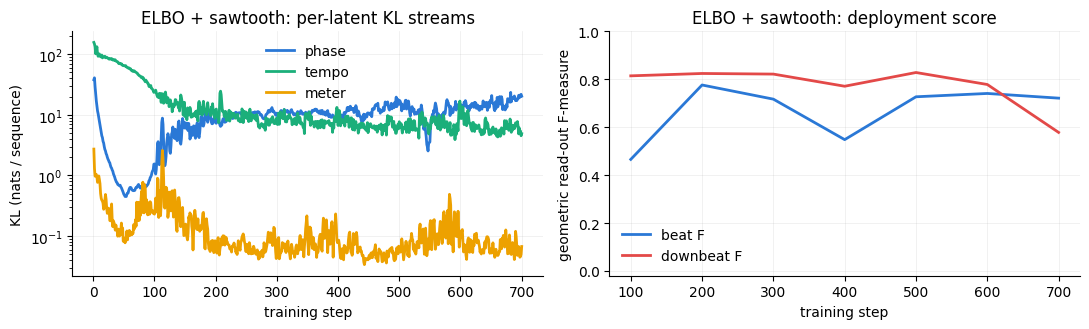

In [ ]:
plot_training_history(sawtooth_history, "ELBO + sawtooth")

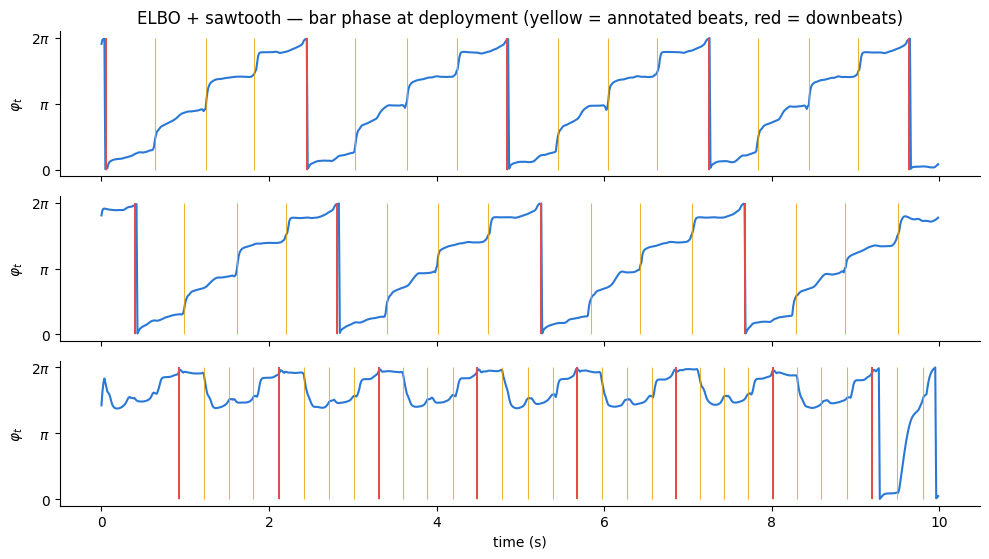


ELBO + sawtooth — geometric read-out on 16 validation songs:
  condition    beat F  downbeat F
  real          0.712       0.598
  shuffle       0.214       0.069
  zero          0.000       0.000
  mechanism (real): phase coverage 0.91, rotation ratio 1.10


In [ ]:
plot_phase_trajectories(sawtooth_model, validation_songs, "ELBO + sawtooth")
print_leak_table(sawtooth_model, validation_songs, "ELBO + sawtooth", EVAL_MAX_FRAMES)

**Reading Experiment 2.** Same architecture, same data, same seeds, same ELBO — plus one dense term.
The bar phase now *sweeps*: coverage and rotation ratio near 1, downbeats where it wraps, beats at the
quarter-points, and the deployment F-measures follow. The leak controls certify the mechanism: with shuffled
or zeroed audio the read-out collapses, so the rotation is driven by *this* song's features, not memorized
periodicity. And note the phase KL stream during training: it stays visibly positive — the model now *pays*
nats every frame to keep an informative phase posterior, because the auxiliary makes an aligned phase worth
paying for.

(In our systematic runs of the same setup outside this notebook, the qualitative split is stable across
seeds: the pure objective collapses on essentially every seed, the grounded one rotates on every seed.
Single runs here keep the notebook's runtime reasonable, and one seed each is honestly representative.)

## 12b. Experiment 3 — deploying through the prior network, and training it (Sohn et al., 2015)

Our model is a **conditional VAE** in the exact sense of Sohn, Lee & Yan (2015): input $\mathbf{x}$ = the
frontend features, output $\mathbf{y}$ = the beat/downbeat channels, and three networks — recognition
$q_\phi(z\mid x,y)$ (our posterior encoder, which reads the annotated events), conditional prior
$p_\theta(z\mid x)$ (our initial prior + transition dynamics, with audio-conditioned scales and meter
transition), and generation $p_\theta(y\mid z)$ (the event decoder; conditioning on $z$ only rather than
$(x,z)$ matches the Pyro reference implementation and keeps the geometric read-out honest — with $x$ in
the decoder, $z$ would be bypassed).

Section 4.2 of the paper names the failure that both experiments above exhibit: *"the CVAE uses the
recognition network at training, but it uses the prior network at testing... Since $y$ is given as an
input for the recognition network, the objective at training can be viewed as a **reconstruction** of
$y$, which is an easier task than prediction."* Our training reconstruction kept improving while
deployment collapsed — that is this sentence, observed. The paper also reports that up-weighting the KL
$-(1+\beta)\,KL$ to force the two pipelines together is **ineffective** (their words), which saves us
that ablation.

Their working remedy is twofold, and this experiment implements both:

1. **Inference through the prior network** (sec. 4.1): $y^* = \arg\max_y p_\theta(y\mid x, z^*)$ with
   $z^* = E[z\mid x]$. That is `rollout_prior(sample=False)` — a deterministic rollout of the
   generative dynamics from the audio-conditioned initial prior. The silent-$y$ recognition read-out used
   until now is kept only as a diagnostic (it feeds the recognition network an input it never saw in
   training).
2. **The GSNN / hybrid objective** (eqs. 8–9): draw $z$ from the prior pipeline with **no $y$ anywhere**,
   reconstruct $y$, and mix: $\widetilde{\mathcal{L}}_{\text{hybrid}} = \alpha\,
   \widetilde{\mathcal{L}}_{\text{CVAE}} + (1-\alpha)\, \widetilde{\mathcal{L}}_{\text{GSNN}}$.
   This trains the *test-time* pipeline directly; in the paper's experiments *"the GSNN performed the
   best among our proposed models [on prediction accuracy], and performed even better when it is trained
   with hybrid objective."*

Two previously-validated deviations ride along: free bits at $\lambda = 0.3$ nats/frame (Kingma et al.
2016; without it the recognition pipeline collapses, §11.1), and the Laplace tempo increment (§1.4).
Meter identification (the M2 supervision) and the soft-meter read-out are deliberately **excluded** here
so this experiment isolates one question: *does training the prediction pipeline lift the prior rollout?*
Watch `rot` (phase revolutions per annotated bar) in the logs — ~1.0 means genuine bar-level tracking,
~4 means the phase has locked to the beat level and the F-scores are level-confusion artifacts.

In [ ]:
print("Experiment 3: hybrid CVAE+GSNN (Sohn et al. 2015, eq. 9) -- alpha = 0.5, free bits 0.3 nats/frame")
print("deployment through the PRIOR network (rollout_prior), per section 4.1 of the paper\n")
hybrid_model, hybrid_history = train_bar_pointer_model(
    num_steps=NUM_TRAINING_STEPS, seed=0, hybrid_alpha=0.5, free_bits_nats_per_frame=0.3)
plot_training_history(hybrid_history, "hybrid CVAE+GSNN")
plot_phase_trajectories(hybrid_model, validation_songs, "hybrid CVAE+GSNN")

## 12c. Experiment 4 — deploying by filtering: the lineage's own inference

The spec (§4–§5 of the derivation) locates the state from audio exactly **once** — the $t{=}1$ initial
prior — and from then on audio only tunes the transition *scales* ($b^p = f_\psi(h)$, $\rho^p =
f_\psi(h)$), never the location. A prior rollout is therefore dead-reckoning, and no ancestor of this
model ever deployed that way: Whiteley et al. (2007) deploy a **particle filter**, madmom deploys
Viterbi — the *likelihood* supplies the per-frame location that the transitions deliberately don't.

`filter_deploy` is that inference on our learned model (ported from the repo's proven
`model/particle_filter.py`): particles propagate through the trained transition priors; the trained
z-only decoder $p(b\mid z)$ scores each particle against the frontend activations $a_t \in [0,1]$
(the cached `act2` — observable at test time) as soft evidence; systematic resampling. Note the spec's
§5.4 decoder reads $(z, h)$ — our z-only decoder is a deviation, but a *load-bearing* one here: an
$h$-reading likelihood could score particles identically and the filter would collapse to the prior
rollout.

**The experiment:** one spec-faithful CVAE (α=1, free bits 0.3), **three deployments on the same
weights** — prior rollout (Sohn §4.1), silent-y recognition (diagnostic), particle filter. If the
filter wins on identical weights, the day's conclusion inverts cleanly: the model was never broken;
the deployment was unfaithful to the lineage.

In [ ]:
print("Experiment 4: one spec-faithful CVAE; THREE deployments on the same weights\n")
cvae_model, cvae_history = train_bar_pointer_model(
    num_steps=NUM_TRAINING_STEPS, seed=0, hybrid_alpha=1.0, free_bits_nats_per_frame=0.3)
deployments = [
    ("prior rollout (Sohn 4.1)", evaluate_prior_readout(cvae_model, validation_songs, EVAL_MAX_FRAMES)),
    ("recognition, silent y (diagnostic)", evaluate_geometric_readout(cvae_model, validation_songs, "real", EVAL_MAX_FRAMES)),
    ("particle filter (Whiteley 2007)", evaluate_filter_readout(cvae_model, validation_songs, EVAL_MAX_FRAMES)),
]
print(f"\n{'deployment':38s} {'beat F':>8} {'downbeat F':>11} {'rot':>6}")
for name, r in deployments:
    print(f"{name:38s} {r['beat_f']:>8.3f} {r['downbeat_f']:>11.3f} {r['rotation_ratio']:>6.2f}")
    if "beat_f_bayes" in r:
        print(f"{'  (Bayesian activation read-out)':38s} {r['beat_f_bayes']:>8.3f} {r['downbeat_f_bayes']:>11.3f}")

## 12d. Experiment 5 — the certified repair stack, together

Three defects, each isolated and repaired in the toy bridge ladder (2026-07-09), composed on the
real model. Every element keeps the derivation intact:

1. **$x$-conditioned transition means** (`transition_correction_scale=0.5`) — bounded residual
   corrections; the toy's rung-3 switch (deploy $-1.1 \to 0.97\ R^2$).
2. **Sawtooth as a dense phase emission** (`sawtooth_weight=0.5`) — kills the between-events gauge
   freedom (toy B2 → B2a: 0.55 → 0.98); formally $-\log p(\tilde\varphi_t \mid \varphi_t)$ under a
   von Mises emission with $\kappa$ = the weight, i.e. an ELBO term of an enriched observation model.
3. **Prior-preserving free-bits** (`prior_preserving_free_bits=True`) — the standard clamp zeroes all
   prior-side gradients whenever KL < floor (this starved the initial tempo prior to 3–215× errors);
   the value-0 correction restores them (cf. DreamerV2 KL balancing). Applied WITH the sawtooth, per
   the toy's fix-order lesson (B3p alone distills an incoherent posterior).

The harness's step-1 gradient-reach check verifies every prior-side network actually receives gradient.

In [ ]:
print("Experiment 5: repair stack -- g-prior + sawtooth emission + prior-preserving free-bits")
stack_model, stack_history = train_bar_pointer_model(
    sawtooth_weight=0.5, free_bits_nats_per_frame=0.3,
    transition_correction_scale=0.5, prior_preserving_free_bits=True)

## 13. The probe: which solution does the pure objective itself prefer?

Now the decisive measurement promised in §11.1. We hold the **objective** fixed — the pure negative ELBO of
§8, no auxiliary — and evaluate it for **both trained parameter sets** on **identical batches with identical
sampling noise** (same crops, same reseed before each model's rollout). Two possible outcomes:

* If the *rotating* weights score a **lower** negative ELBO, collapse was an optimization trap: the optimizer
  failed to find a better optimum that was there all along. Optimizer-side fixes are then justified.
* If the *collapsed* weights score **lower**, then the pure objective genuinely prefers ignorance of the
  phase: the informative posterior's KL bill exceeds what reconstruction pays back. Collapse is the
  objective's optimum — no optimizer trick can fix a preference — and *changing the objective* (as the
  auxiliary does) is not a hack but the only kind of move that can work.

In [ ]:
vanilla_accounting = pure_negative_elbo_accounting(
    vanilla_model, train_songs, negative_elbo_terms, CROP_LENGTH_FRAMES, BATCH_SIZE)
sawtooth_accounting = pure_negative_elbo_accounting(
    sawtooth_model, train_songs, negative_elbo_terms, CROP_LENGTH_FRAMES, BATCH_SIZE)

print(f"pure -ELBO accounting (nats/sequence, mean over shared batches; lower = preferred by the objective)\n")
print(f"  {'term':<16} {'collapsed':>12} {'rotating':>12} {'difference':>12}")
for term_name in ("reconstruction", "kl_meter", "kl_phase", "kl_tempo", "total"):
    collapsed_value = vanilla_accounting[term_name]
    rotating_value = sawtooth_accounting[term_name]
    print(f"  {term_name:<16} {collapsed_value:>12.2f} {rotating_value:>12.2f} "
          f"{rotating_value - collapsed_value:>+12.2f}")

preferred = "COLLAPSED" if vanilla_accounting["total"] < sawtooth_accounting["total"] else "ROTATING"
print(f"\nthe pure objective prefers the {preferred} solution "
      f"(margin {abs(vanilla_accounting['total'] - sawtooth_accounting['total']):.2f} nats/sequence)")

pure -ELBO accounting (nats/sequence, mean over shared batches; lower = preferred by the objective)

  term                collapsed     rotating   difference
  reconstruction          36.71        36.56        -0.16
  kl_meter                 0.03         0.05        +0.03
  kl_phase                 0.03        19.17       +19.14
  kl_tempo                 8.93         5.17        -3.75
  total                   45.70        60.95       +15.26

the pure objective prefers the COLLAPSED solution (margin 15.26 nats/sequence)


## 14. Reading the probe

The accounting table is the whole story in four rows:

* **The rotating solution pays a large phase-KL bill.** Keeping an informative phase posterior means, at
  every one of the 256 frames, proposing a $\varphi_t$ that the audio supports rather than whatever the prior
  would have drifted to — and eq. (12) charges nats for every such correction. Summed over the sequence, this
  is the dominant difference between the two columns.
* **Reconstruction pays back only a little.** The events are *sparse* binary channels: a decoder that knows
  the true phase beats the blind base-rate decoder by far fewer nats than the posterior's KL bill. The
  information-theoretic ceiling on the payback is the entropy of the event sequence itself, and at ~2 beat
  frames per second that ceiling is low.
* So the pure objective's ledger says: **ignorance is cheaper.** The collapsed column wins in total. Training
  the pure objective did not malfunction in §11 — it *succeeded* at the wrong thing. That is why every
  optimizer-side remedy (warm-up, free bits, dropout, longer training) merely changes the path to the same
  preferred point, while a term that changes *what is preferred* — the sawtooth, eq. (14) — changes the
  outcome. And because the auxiliary re-uses the labels the likelihood already sees, the fix costs no new
  supervision: it re-prices the latent's alignment from "taxed luxury" to "paid work."

One caveat, stated plainly: the probe compares the two solutions *found by these two trainings*, not all
possible optima of the objective. Strictly, it proves the objective prefers this collapsed solution over this
rotating one — the converse of "collapse is a trap," whose signature (rotating scoring better) we do not
observe. Sharper versions of the same conclusion (e.g. warm-starting the pure objective *from* the rotating
weights and watching it dismantle the rotation) are natural follow-ups and behave as this table predicts.

## 15. Summary, and what was deliberately simplified

**What this notebook established, end to end:**

1. A bar-pointer generative model with three matched latent families (Categorical meter, wrapped Cauchy bar phase,
   Log-Laplace tempo), an amortized autoregressive posterior, and a fully derived ELBO — every KL in closed
   form, every sampler reparameterized (the wrapped Cauchy phase by a direct inverse-CDF transform of
   uniform noise, giving gradients through both mean and concentration).
2. Trained on its pure objective, the model posterior-collapses: the phase KL vanishes, the pointer freezes,
   deployment fails — while the loss happily decreases.
3. The collapse is the **objective's preference**, not an optimization accident: on identical batches and
   noise, the pure negative ELBO scores the collapsed weights better than rotating weights of the same
   architecture, because sparse Bernoulli reconstruction cannot repay a per-frame informative-posterior tax.
4. One dense auxiliary — a sawtooth bar-phase target built from the *same* annotations, with a circular
   $1-\cos$ loss — re-prices alignment and yields a sweeping, audio-locked pointer whose geometry *is* the
   beat/downbeat estimate (verified by shuffle/zero leak controls).

**Deliberate simplifications** (demonstration scale, none load-bearing for the argument): one seed per
experiment and a small step budget; a fixed $M{=}4$ sawtooth target and read-out (the meter latent is
inferred but not consequential here — making it so is real modeling work, not notebook work); a frozen
frontend; a bidirectional (smoothing) encoder; single-sample KL estimates; no tempo-octave analysis.
Each is a doorway into the actual research frontier this demonstration sits at the base of.